In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.integrate as si
from scipy.optimize import root_scalar

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')

In [6]:
from acsmuthi.linear_system.coupling.coupling_basics import k_contour
from acsmuthi.medium import FluidMedium, ElasticMedium, RigidBoundary, MediumSystem, fresnel_r_elastic

In [3]:
def fresnel_den(k_parallel, k_medium, c_medium, cl_substrate, ct_substrate, rho_medium, rho_substrate):
    omega = k_medium * c_medium
    k_sub_d = omega / cl_substrate
    k_sub_s = omega / ct_substrate

    kz_med = np.emath.sqrt(k_medium**2 - k_parallel**2)
    gz_d = np.emath.sqrt(k_parallel**2 - k_sub_d**2)
    gz_s = np.emath.sqrt(k_parallel**2 - k_sub_s**2)

    term1 = (2 * k_parallel**2 - k_sub_s**2)**2
    term2 = 4 * k_parallel**2 * gz_s * gz_d
    term3 = 1j * rho_medium / rho_substrate * k_sub_s**4 * gz_d / kz_med
    return (term1 - term2 + term3)

### impedance dependence

In [7]:
_freq = 2e6

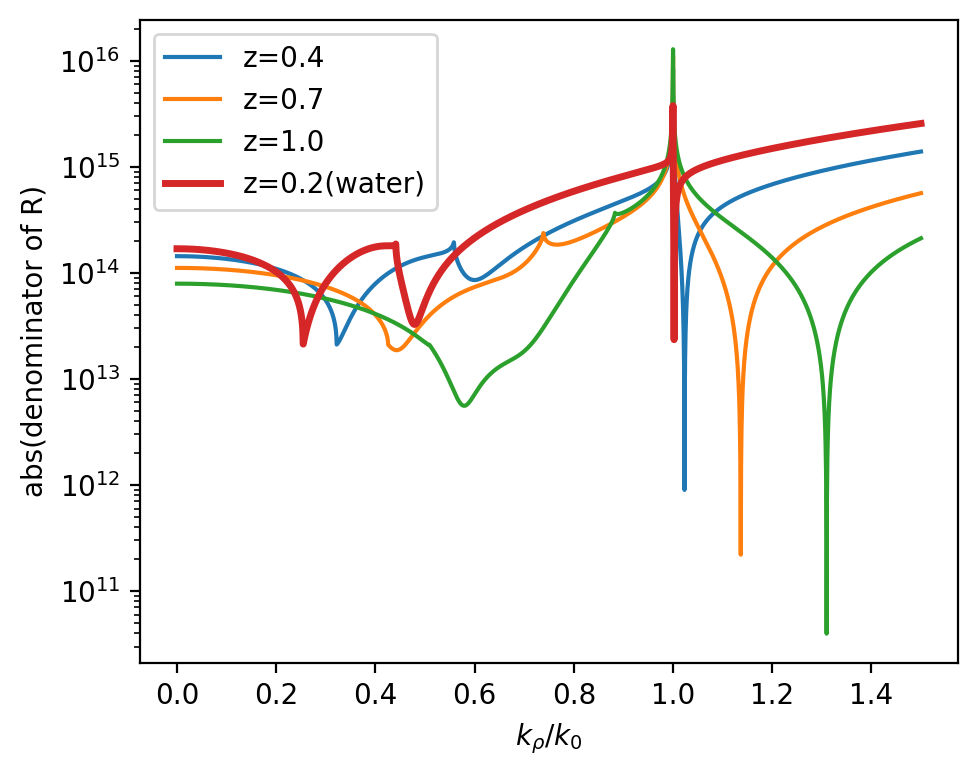

In [5]:
quartz = ElasticMedium(density=2650, sound_speed_longitudinal=5900, sound_speed_transversal=3400)

kp_re = np.linspace(0, 1.5, 5_000)
z_q = quartz.c_transversal * quartz.density

_, ax = plt.subplots(figsize=(5, 4))

for z in np.linspace(0.4, 1, 3):
    fluid = FluidMedium(density=np.sqrt(z*z_q), sound_speed_longitudinal=np.sqrt(z*z_q))
    k0 = fluid.wavenumber(_freq)
    k_pars = kp_re * k0
    den = fresnel_den(k_pars, k0, fluid.c_longitudinal, quartz.c_longitudinal, quartz.c_transversal, fluid.density, quartz.density)
    ax.plot(k_pars / k0, abs(den), label=f'z={z:.1f}')


water = FluidMedium(density=1000, sound_speed_longitudinal=1500)
k0 = water.wavenumber(_freq)
k_pars = kp_re * k0
z_w = water.c_longitudinal*water.density
den = fresnel_den(k_pars, k0, water.c_longitudinal, quartz.c_longitudinal, quartz.c_transversal, water.density, quartz.density)
ax.semilogy(k_pars / k0, abs(den), lw=2.5, label=f'z={z_w/z_q:.1f}(water)')


ax.set(xlabel='$k_{\\rho}/k_0$', ylabel='abs(denominator of R)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

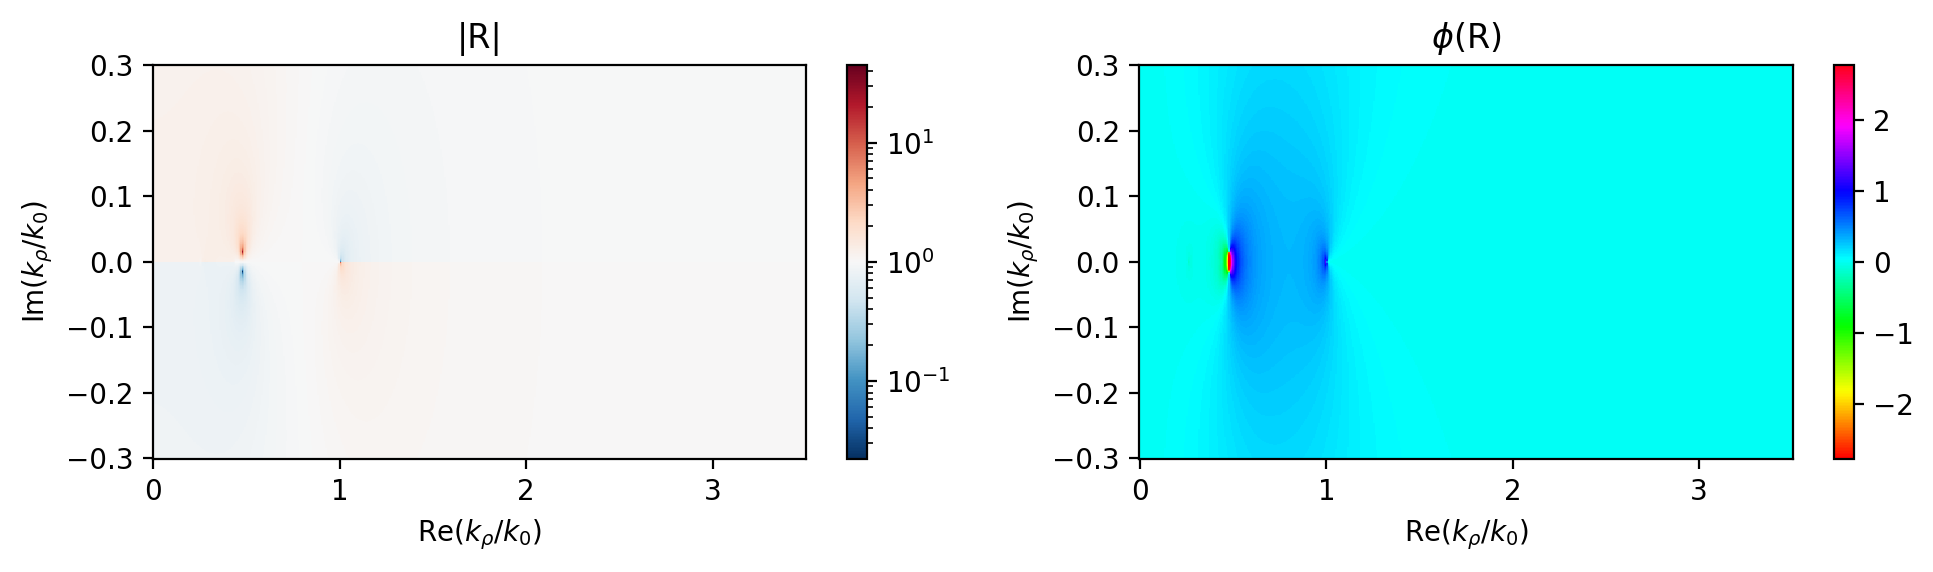

In [45]:
quartz = ElasticMedium(density=2650, sound_speed_longitudinal=5900, sound_speed_transversal=3400)
water = FluidMedium(density=1000, sound_speed_longitudinal=1500)
ms = MediumSystem([water, quartz])

k0 = water.wavenumber(_freq)
fr_func = lambda kp: ms.fresnel_r(kp, _freq)

kpr = np.linspace(0, 3.5, 500)
kpi = np.linspace(-.3, .3, 500)
krr, kii = np.meshgrid(kpr, kpi)
fresnel_r = fr_func((krr + kii * 1j) * k0)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
imr = ax[0].pcolormesh(kpr, kpi, np.abs(fresnel_r), norm=mpl.colors.LogNorm(), cmap='RdBu_r')
imi = ax[1].pcolormesh(kpr, kpi, np.angle(fresnel_r), norm=mpl.colors.CenteredNorm(), cmap='hsv')

ax[0].set(xlabel='Re($k_{\\rho}/k_0$)', ylabel='Im($k_{\\rho}/k_0$)', title='|R|', aspect='auto')
ax[1].set(xlabel='Re($k_{\\rho}/k_0$)', ylabel='Im($k_{\\rho}/k_0$)', title='$\\phi$(R)', aspect='auto')
plt.colorbar(imr, ax=ax[0]), plt.colorbar(imi, ax=ax[1])
plt.tight_layout()
plt.show()

c:\Users\kvd\AppData\Local\pypoetry\Cache\virtualenvs\acsmuthi-TZOMr8Wr-py3.11\Lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


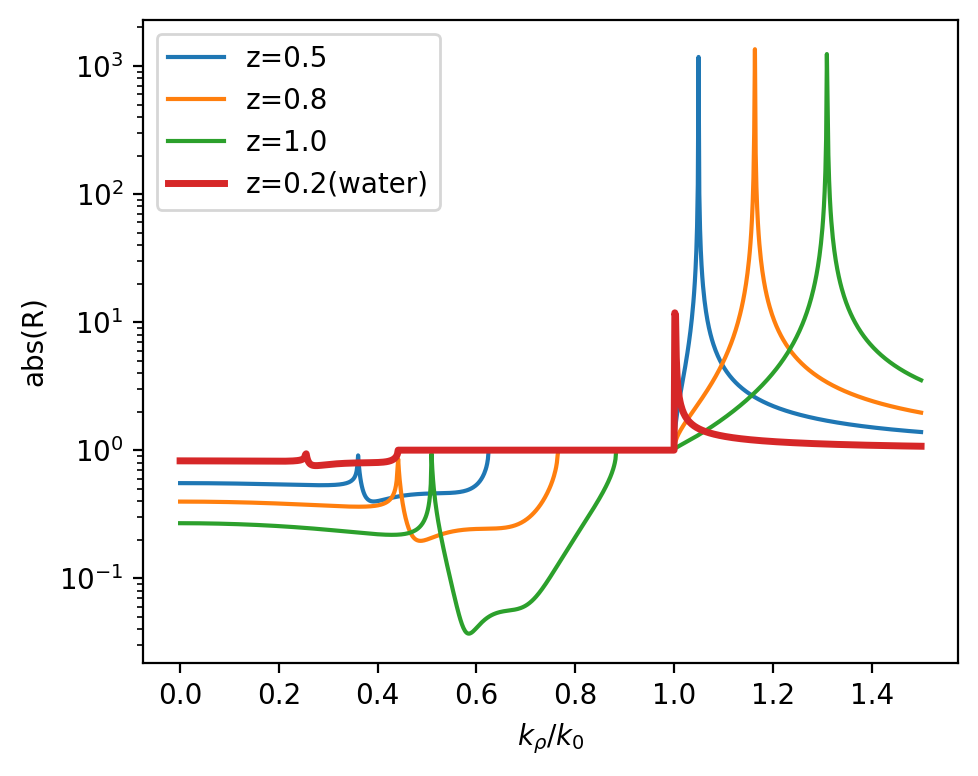

In [7]:
quartz = ElasticMedium(density=2650, sound_speed_longitudinal=5900, sound_speed_transversal=3400)

kp_re = np.linspace(0, 1.5, 1_000) - 1e-15j
z_q = quartz.c_transversal * quartz.density

_, ax = plt.subplots(figsize=(5, 4))

for z in np.linspace(0.5, 1, 3):
    fluid = FluidMedium(density=np.sqrt(z*z_q), sound_speed_longitudinal=np.sqrt(z*z_q))
    k0 = fluid.wavenumber(_freq)
    k_pars = kp_re * k0
    fr = MediumSystem([fluid, quartz]).fresnel_r(k_pars, _freq)
    ax.plot(k_pars / k0, abs(fr), label=f'z={z:.1f}')

water = FluidMedium(density=1000, sound_speed_longitudinal=1500)
k0 = water.wavenumber(_freq)
k_pars = kp_re * k0
z_w = water.c_longitudinal*water.density
fr = MediumSystem([water, quartz]).fresnel_r(k_pars, _freq)
ax.semilogy(k_pars / k0, abs(fr), lw=2.5, label=f'z={z_w/z_q:.1f}(water)')


ax.set(xlabel='$k_{\\rho}/k_0$', ylabel='abs(R)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

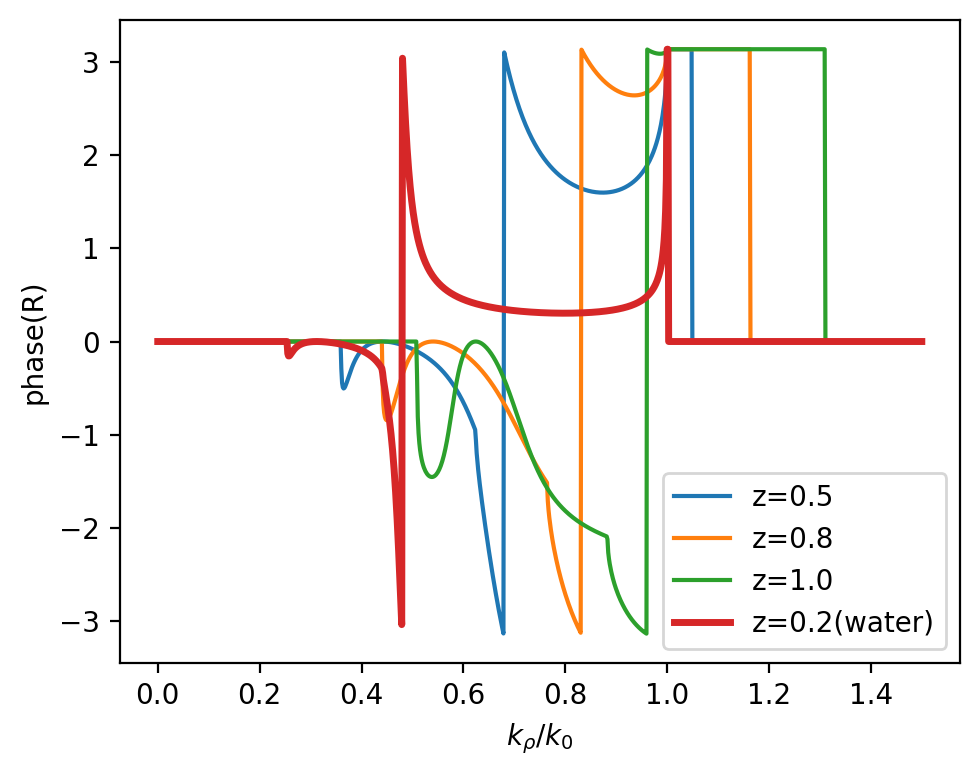

In [8]:
quartz = ElasticMedium(density=2650, sound_speed_longitudinal=5900, sound_speed_transversal=3400)

kp_re = np.linspace(0, 1.5, 1_000) - 1e-15j
z_q = quartz.c_transversal * quartz.density

_, ax = plt.subplots(figsize=(5, 4))

for z in np.linspace(0.5, 1, 3):
    fluid = FluidMedium(density=np.sqrt(z*z_q), sound_speed_longitudinal=np.sqrt(z*z_q))
    k0 = fluid.wavenumber(_freq)
    k_pars = kp_re * k0
    fr = MediumSystem([fluid, quartz]).fresnel_r(k_pars, _freq)
    ax.plot(k_pars / k0, np.angle(fr), label=f'z={z:.1f}')

water = FluidMedium(density=1000, sound_speed_longitudinal=1500)
k0 = water.wavenumber(_freq)
k_pars = kp_re * k0
z_w = water.c_longitudinal*water.density
fr = MediumSystem([water, quartz]).fresnel_r(k_pars, _freq)
ax.plot(k_pars / k0, np.angle(fr), lw=2.5, label=f'z={z_w/z_q:.1f}(water)')


ax.set(xlabel='$k_{\\rho}/k_0$', ylabel='phase(R)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### roots existance

In [ ]:
# rho0 = 1000
# c0 = 1500

# c0_ct = np.linspace(0.1, 10)
# c0_cl = np.linspace(0.1, 10)

# c0t, c0l = np.meshgrid(c0_ct, c0_cl)
# rho0_rhos = [0.1, 0.5, 1., 1.5, 3]

# for rho_rel in rho0_rhos:
#     _, ax = plt.subplots(figsize=(5, 3))
#     den = fresnel_den()
    

### resin

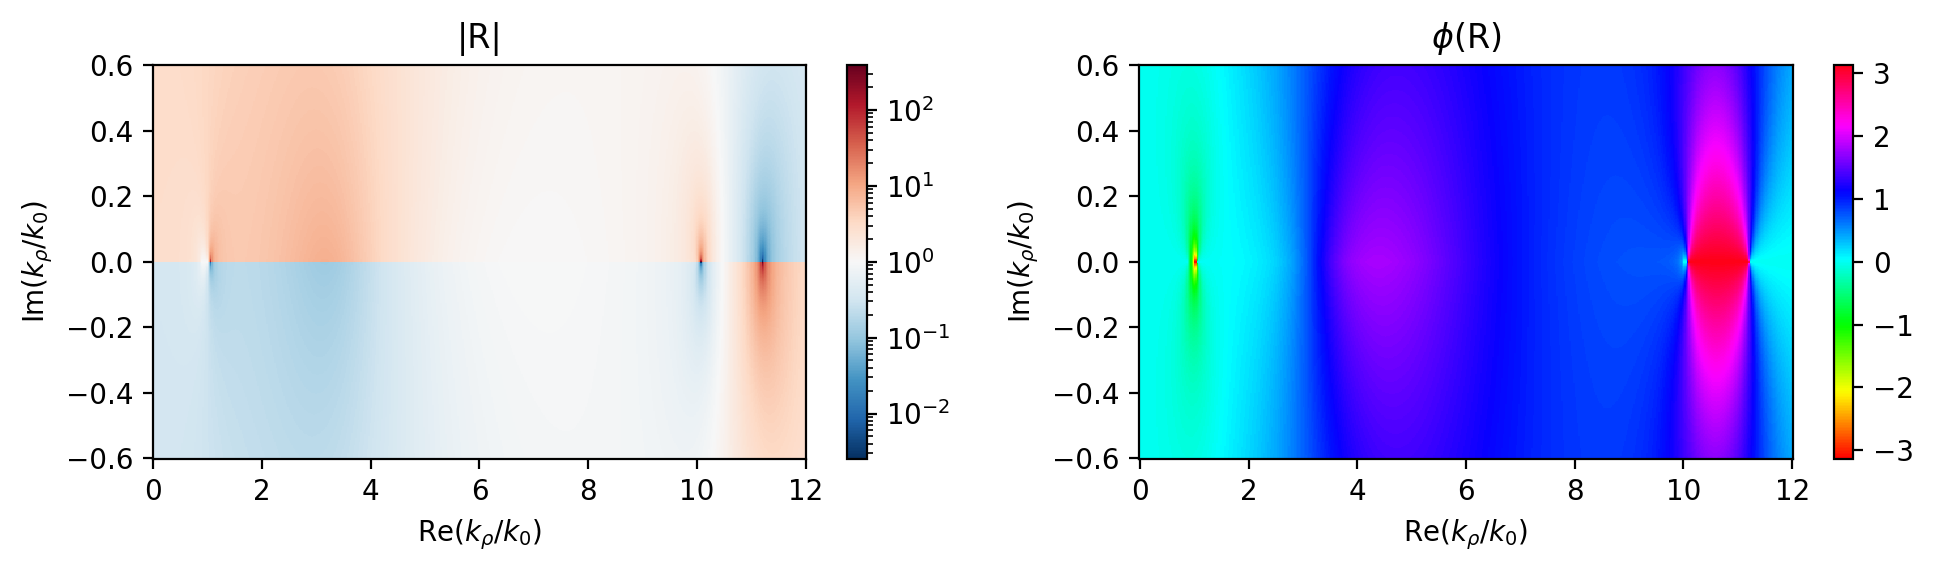

In [52]:
# rubber
rubber = ElasticMedium(density=1800, sound_speed_longitudinal=1700, sound_speed_transversal=150)
water = FluidMedium(density=1000, sound_speed_longitudinal=1500)
ms = MediumSystem([water, rubber])

k0 = water.wavenumber(_freq)
fr_func = lambda kp: ms.fresnel_r(kp, _freq)

kpr = np.linspace(0., 12, 500)
kpi = np.linspace(-0.6, 0.6, 500)
krr, kii = np.meshgrid(kpr, kpi)
fresnel_r = fr_func((krr + kii * 1j) * k0)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
imr = ax[0].pcolormesh(kpr, kpi, np.abs(fresnel_r), norm=mpl.colors.LogNorm(), cmap='RdBu_r')
imi = ax[1].pcolormesh(kpr, kpi, np.angle(fresnel_r), norm=mpl.colors.CenteredNorm(), cmap='hsv')

ax[0].set(xlabel='Re($k_{\\rho}/k_0$)', ylabel='Im($k_{\\rho}/k_0$)', title='|R|', aspect='auto')
ax[1].set(xlabel='Re($k_{\\rho}/k_0$)', ylabel='Im($k_{\\rho}/k_0$)', title='$\\phi$(R)', aspect='auto')
plt.colorbar(imr, ax=ax[0]), plt.colorbar(imi, ax=ax[1])
plt.tight_layout()
plt.show()

In [54]:
gamma = 1700 / 150
sigma = (gamma**2 - 2) / (gamma**2 - 1) / 2
sigma

0.4960767218831735

In [48]:
water.c_longitudinal/1067, water.c_longitudinal/1381

(1.4058106841611997, 1.0861694424330195)

In [51]:
def find_k_sch_prec(kf, rho_f, rho_s, kl, kt):
    def ray_opt(k):
        gl = np.emath.sqrt(k**2 - kl**2)
        gt = np.emath.sqrt(k**2 - kt**2)
        gf = np.emath.sqrt(kf**2 - k**2)
        return (2 * k**2 - kt**2)**2 - 4 * k**2 * gl * gt + 1j * rho_f / rho_s * kt**4 * gl / gf
    return root_scalar(ray_opt, x0=kf*1.0001, x1=kf*1.02).root
k_sch = find_k_sch_prec(k0, water.density, rubber.density, rubber.wavenumber(_freq), rubber.wavenumber_transversal(_freq))
k0/k_sch, k_sch/k0

((1.261656148276098-0.018080865057169278j),
 (0.7924462337608443+0.011356591443135673j))

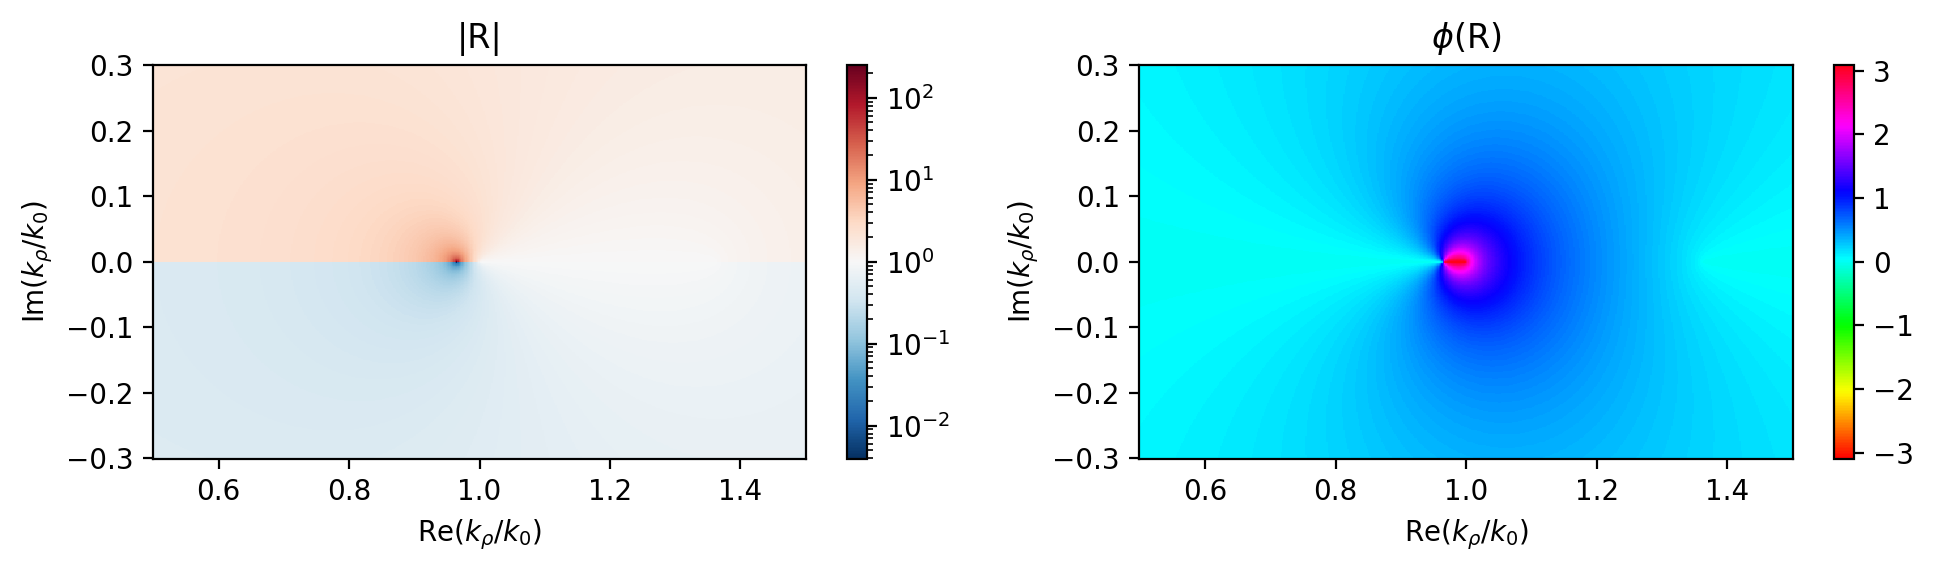

In [ ]:
# rubber
rubber = ElasticMedium(density=3800, sound_speed_longitudinal=1100, sound_speed_transversal=150)
water = FluidMedium(density=1000, sound_speed_longitudinal=1500)
ms = MediumSystem([water, rubber])

k0 = water.wavenumber(_freq)
fr_func = lambda kp: ms.fresnel_r(kp, _freq)

kpr = np.linspace(0.5, 1.5, 500)
kpi = np.linspace(-0.3, 0.3, 500)
krr, kii = np.meshgrid(kpr, kpi)
fresnel_r = fr_func((krr + kii * 1j) * k0)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
imr = ax[0].pcolormesh(kpr, kpi, np.abs(fresnel_r), norm=mpl.colors.LogNorm(), cmap='RdBu_r')
imi = ax[1].pcolormesh(kpr, kpi, np.angle(fresnel_r), norm=mpl.colors.CenteredNorm(), cmap='hsv')

ax[0].set(xlabel='Re($k_{\\rho}/k_0$)', ylabel='Im($k_{\\rho}/k_0$)', title='|R|', aspect='auto')
ax[1].set(xlabel='Re($k_{\\rho}/k_0$)', ylabel='Im($k_{\\rho}/k_0$)', title='$\\phi$(R)', aspect='auto')
plt.colorbar(imr, ax=ax[0]), plt.colorbar(imi, ax=ax[1])
plt.tight_layout()
plt.show()

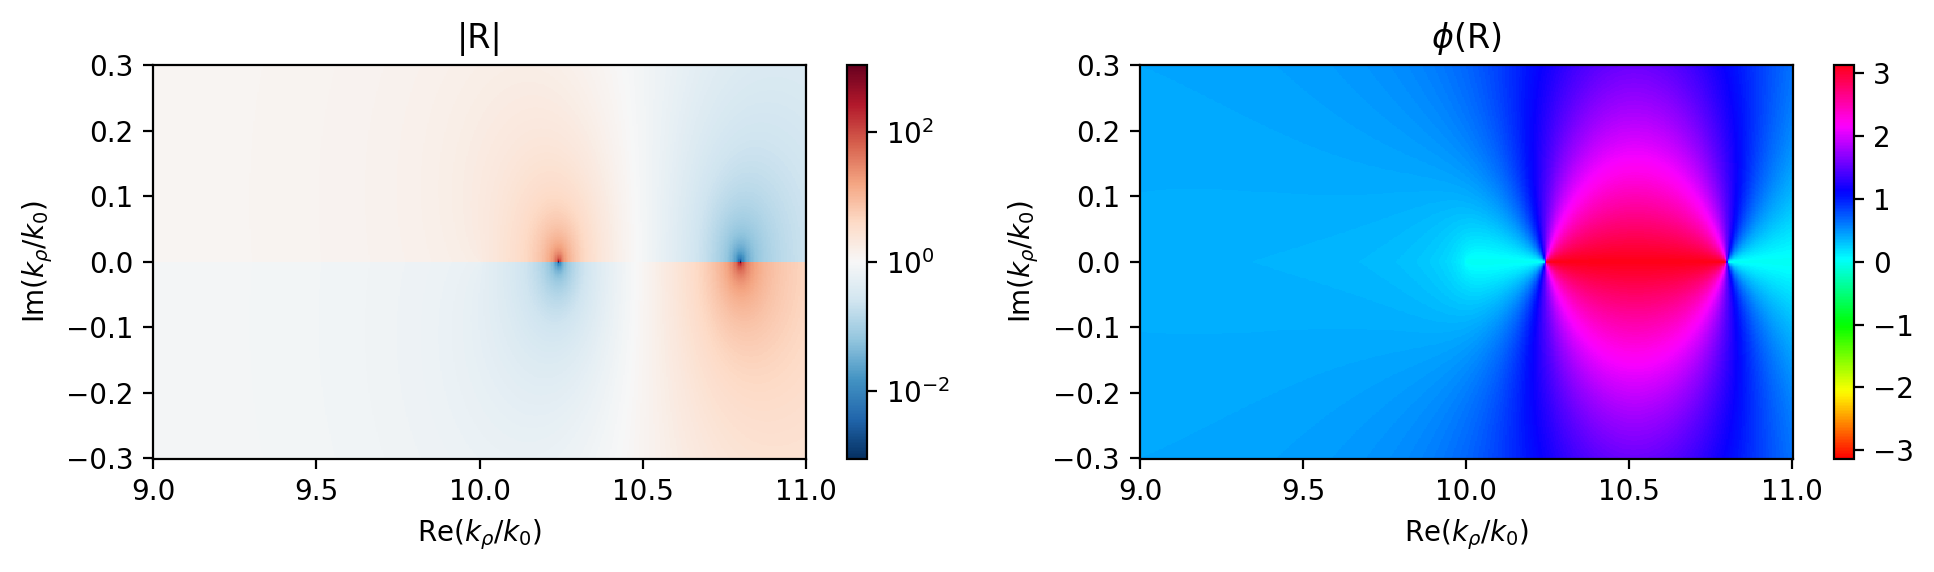

In [ ]:
# rubber
rubber = ElasticMedium(density=3800, sound_speed_longitudinal=1100, sound_speed_transversal=150)
water = FluidMedium(density=1000, sound_speed_longitudinal=1500)
ms = MediumSystem([water, rubber])

k0 = water.wavenumber(_freq)
fr_func = lambda kp: ms.fresnel_r(kp, _freq)

kpr = np.linspace(9, 11, 500)
kpi = np.linspace(-0.3, 0.3, 500)
krr, kii = np.meshgrid(kpr, kpi)
fresnel_r = fr_func((krr + kii * 1j) * k0)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
imr = ax[0].pcolormesh(kpr, kpi, np.abs(fresnel_r), norm=mpl.colors.LogNorm(), cmap='RdBu_r')
imi = ax[1].pcolormesh(kpr, kpi, np.angle(fresnel_r), norm=mpl.colors.CenteredNorm(), cmap='hsv')

ax[0].set(xlabel='Re($k_{\\rho}/k_0$)', ylabel='Im($k_{\\rho}/k_0$)', title='|R|', aspect='auto')
ax[1].set(xlabel='Re($k_{\\rho}/k_0$)', ylabel='Im($k_{\\rho}/k_0$)', title='$\\phi$(R)', aspect='auto')
plt.colorbar(imr, ax=ax[0]), plt.colorbar(imi, ax=ax[1])
plt.tight_layout()
plt.show()

### residue calculation

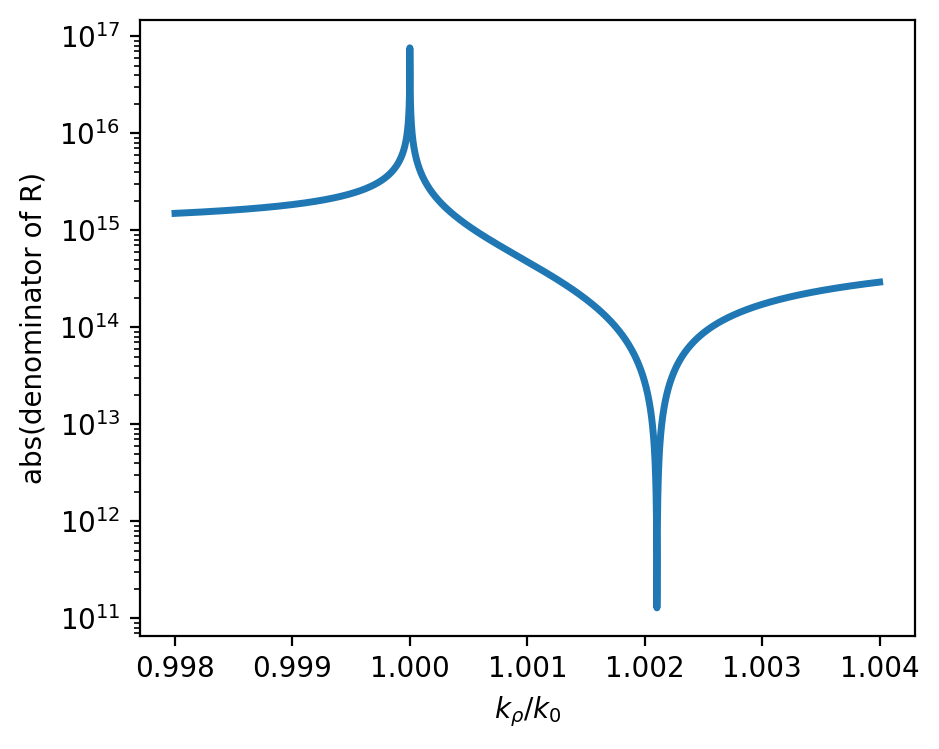

In [9]:
quartz = ElasticMedium(density=2650, sound_speed_longitudinal=5900, sound_speed_transversal=3400)

kp_re = np.linspace(0.998, 1.004, 5_000)
z_q = quartz.c_transversal * quartz.density

_, ax = plt.subplots(figsize=(5, 4))

water = FluidMedium(density=1000, sound_speed_longitudinal=1500)
k0 = water.wavenumber(_freq)
k_pars = kp_re * k0
z_w = water.c_longitudinal*water.density
den = fresnel_den(k_pars, k0, water.c_longitudinal, quartz.c_longitudinal, quartz.c_transversal, water.density, quartz.density)
ax.semilogy(k_pars / k0, abs(den), lw=2.5)


ax.set(xlabel='$k_{\\rho}/k_0$', ylabel='abs(denominator of R)')
plt.show()

In [10]:
def find_k_lrw(kf, rho_f, rho_s, kl, kt):
    def ray_opt(k):
        gl = np.emath.sqrt(k**2 - kl**2)
        gt = np.emath.sqrt(k**2 - kt**2)
        gf = np.emath.sqrt(kf**2 - k**2)
        return (2 * k**2 - kt**2)**2 - 4 * k**2 * gl * gt + 1j * rho_f / rho_s * kt**4 * gl / gf
    return root_scalar(ray_opt, x0=kt, x1=kt+0.1*kf).root


def find_k_sch(kf, rho_f, rho_s, kl, kt):
    def ray_opt(k):
        gl = np.emath.sqrt(k**2 - kl**2)
        gt = np.emath.sqrt(k**2 - kt**2)
        gf = np.emath.sqrt(kf**2 - k**2)
        return (2 * k**2 - kt**2)**2 - 4 * k**2 * gl * gt + 1j * rho_f / rho_s * kt**4 * gl / gf
    return root_scalar(ray_opt, x0=kf*1.01, x1=kf*1.1).root


def residue(func, pole, rad=None):
    if rad is None:
        rad = 0.1 * min(abs(np.real(pole)), abs(np.imag(pole)))

    def integrand(theta):
        z = pole + rad * np.exp(1j * theta)
        return func(z) * 1j * np.exp(1j * theta) * rad

    return si.quad(integrand, 0, 2 * np.pi, complex_func=True)[0] / 2 / np.pi / 1j


def half_residue(func, pole, rad=None):
    if rad is None:
        rad = 0.1 * min(abs(np.real(pole)), abs(np.imag(pole)))

    def integrand(theta):
        z = pole + rad * np.exp(1j * theta)
        return func(z) * 1j * np.exp(1j * theta) * rad

    return si.quad(integrand, np.pi, 2*np.pi, complex_func=True)[0] / 2 / np.pi / 1j

In [11]:
def find_k_sch_prec(kf, rho_f, rho_s, kl, kt):
    def ray_opt(k):
        gl = np.emath.sqrt(k**2 - kl**2)
        gt = np.emath.sqrt(k**2 - kt**2)
        gf = np.emath.sqrt(kf**2 - k**2)
        return (2 * k**2 - kt**2)**2 - 4 * k**2 * gl * gt + 1j * rho_f / rho_s * kt**4 * gl / gf
    return root_scalar(ray_opt, x0=kf*1.002, x1=kf*1.0025).root

#### poles

In [12]:
quartz = ElasticMedium(density=2650, sound_speed_longitudinal=5900, sound_speed_transversal=3400)
water = FluidMedium(density=1000, sound_speed_longitudinal=1500)
ms = MediumSystem([water, quartz])

k0 = water.wavenumber(_freq)

fr_func = lambda kp: ms.fresnel_r(kp, _freq)

k_lrw = find_k_lrw(k0, water.density, quartz.density, quartz.wavenumber(_freq), quartz.wavenumber_transversal(_freq))
k_sch = find_k_sch_prec(k0, water.density, quartz.density, quartz.wavenumber(_freq), quartz.wavenumber_transversal(_freq))

k_sch_fail = find_k_sch(k0, fluid.density, quartz.density, quartz.wavenumber(_freq), quartz.wavenumber_transversal(_freq))

print(f"k-LRW: {k_lrw/k0:.4f}")
print(f"k-SCH: {k_sch/k0:.4f}")
print(f"\nk-SCH bad precision: {k_sch_fail/k0:.4f}")

k-LRW: 0.4776+0.0152j
k-SCH: 1.0021+0.0000j

k-SCH bad precision: 0.4609+0.0428j


In [13]:
lrw_res = residue(fr_func, k_lrw, rad=0.1 * np.imag(k_lrw))
sch_res = residue(fr_func, k_sch, rad=0.0005*k0)

print(f"Residue LRW: {lrw_res:.2f}")
print(f"Residue SCH: {sch_res:.2f}")
print(f"    SCH/LRW: {abs(sch_res)/abs(lrw_res):.3f}")

Residue LRW: -70.66+250.58j
Residue SCH: 35.01-2.64j
    SCH/LRW: 0.135


In [14]:
_freq/1e6

2.0

In [15]:
k_sch/k0

(1.0021041301622202+0j)

In [16]:
np.exp(1j*np.sqrt(k0**2 - k_sch**2)*300E-6)

(0.8494853258410244+0j)

#### lrw

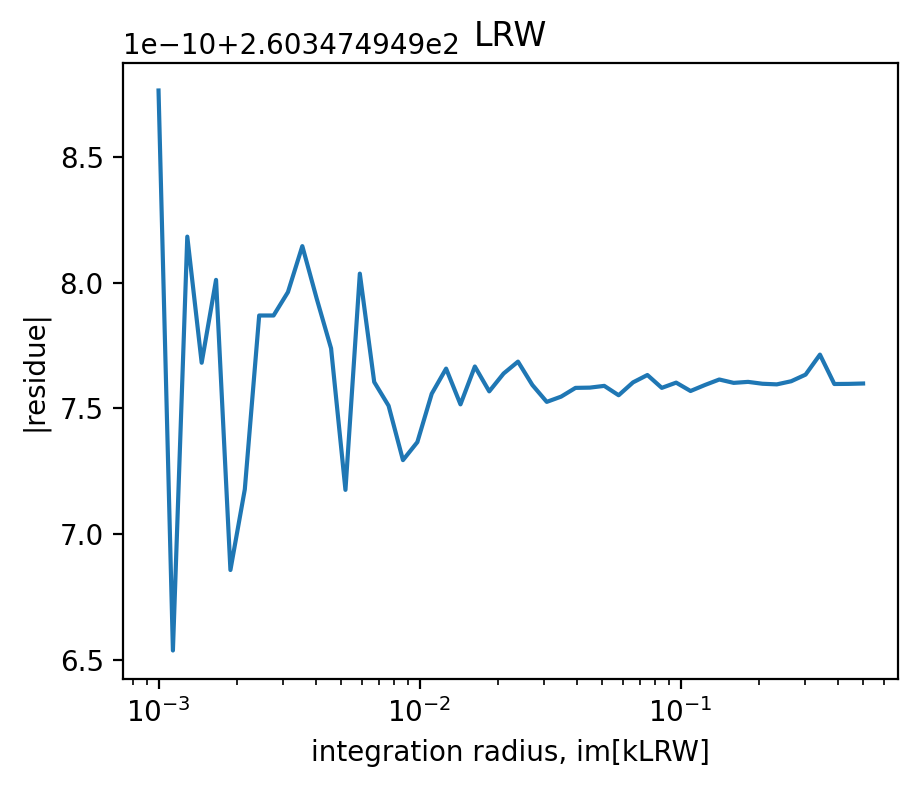

In [17]:
radii = np.geomspace(1e-3, 0.5)
residues = np.zeros(len(radii))

for i, rad in enumerate(radii):
    radius = rad * np.imag(k_lrw)
    res = residue(fr_func, k_lrw, rad=radius)
    residues[i] = abs(res)
        
_, ax = plt.subplots(figsize=(5, 4))
ax.semilogx(radii, residues)
ax.set(xlabel='integration radius, im[kLRW]', ylabel='|residue|', title='LRW')
plt.show()

In [18]:
lrw_res = residue(fr_func, k_lrw, rad=0.1 * np.imag(k_lrw))
print(f"Residue LRW: {lrw_res:.2f}")

Residue LRW: -70.66+250.58j


#### around k0

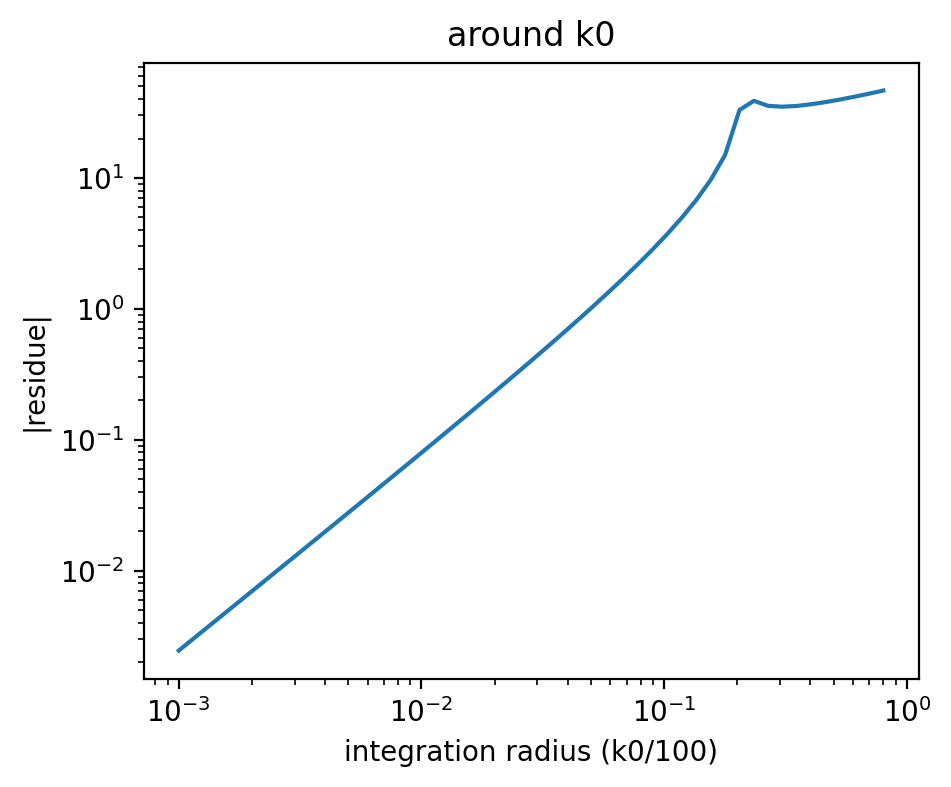

In [19]:
fr_func = lambda kp: ms.fresnel_r(kp, _freq)

radii = np.geomspace(1e-3, 0.8)
residues = np.zeros(len(radii))

for i, rad in enumerate(radii):
    radius = rad * k0/100
    res = residue(fr_func, k0, rad=radius)
    residues[i] = abs(res)
        
_, ax = plt.subplots(figsize=(5, 4))
ax.loglog(radii, residues)
ax.set(xlabel='integration radius (k0/100)', ylabel='|residue|', title='around k0')
plt.show()

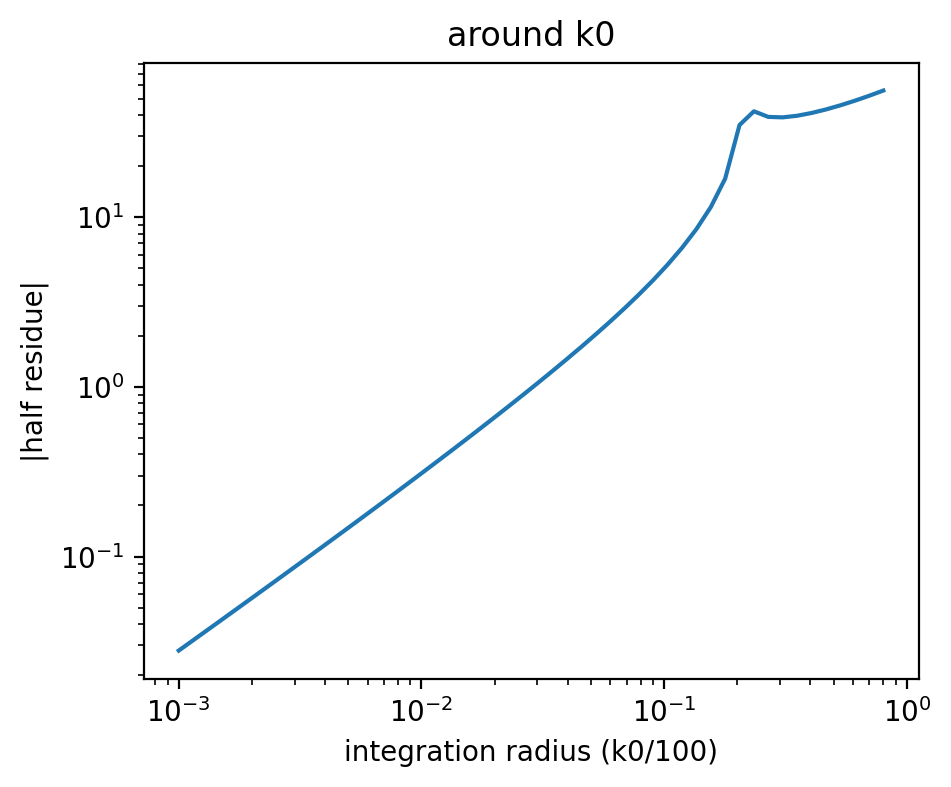

In [20]:
fr_func = lambda kp: ms.fresnel_r(kp, _freq)

radii = np.geomspace(1e-3, 0.8)
residues = np.zeros(len(radii))

for i, rad in enumerate(radii):
    radius = rad * k0/100
    res = half_residue(fr_func, k0, rad=radius)
    residues[i] = abs(res)
        
_, ax = plt.subplots(figsize=(5, 4))
ax.loglog(radii, residues)
ax.set(xlabel='integration radius (k0/100)', ylabel='|half residue|', title='around k0')
plt.show()

#### scholte

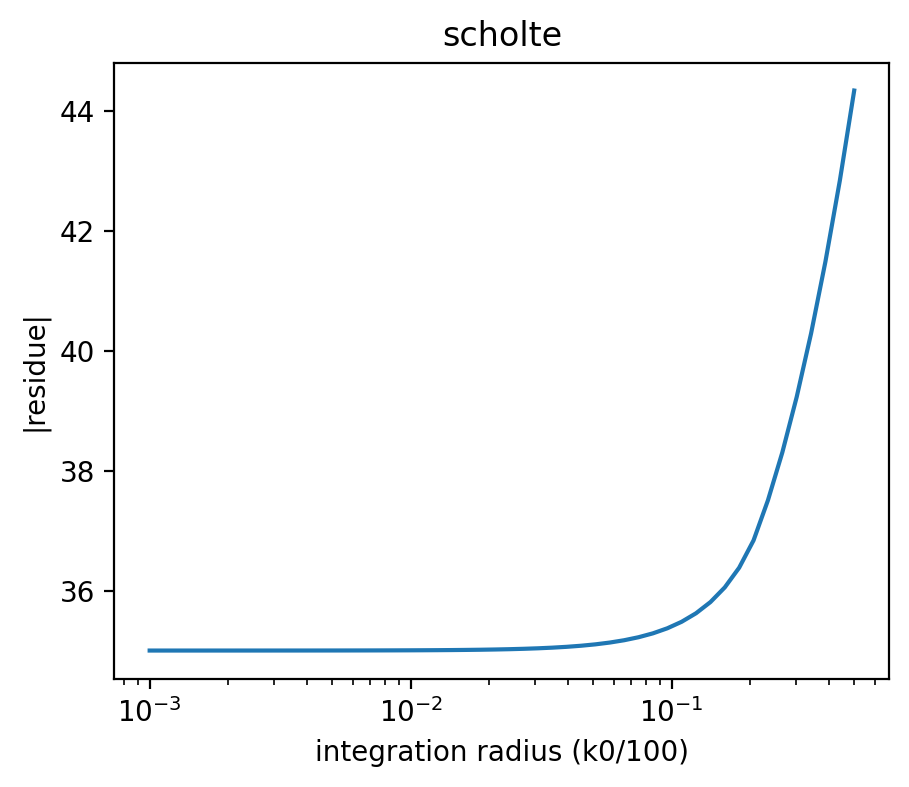

In [21]:
radii = np.geomspace(1e-3, 0.5)
residues = np.zeros(len(radii))

for i, rad in enumerate(radii):
    radius = rad * k0/100
    res = residue(fr_func, k_sch, rad=radius)
    residues[i] = abs(res)

_, ax = plt.subplots(figsize=(5, 4))
ax.semilogx(radii, residues)
ax.set(xlabel='integration radius (k0/100)', ylabel='|residue|', title='scholte')
plt.show()

In [22]:
sch_res = residue(fr_func, k_sch, rad=0.0005*k0)
print(f"Residue SCH: {sch_res:.2f}")

Residue SCH: 35.01-2.64j


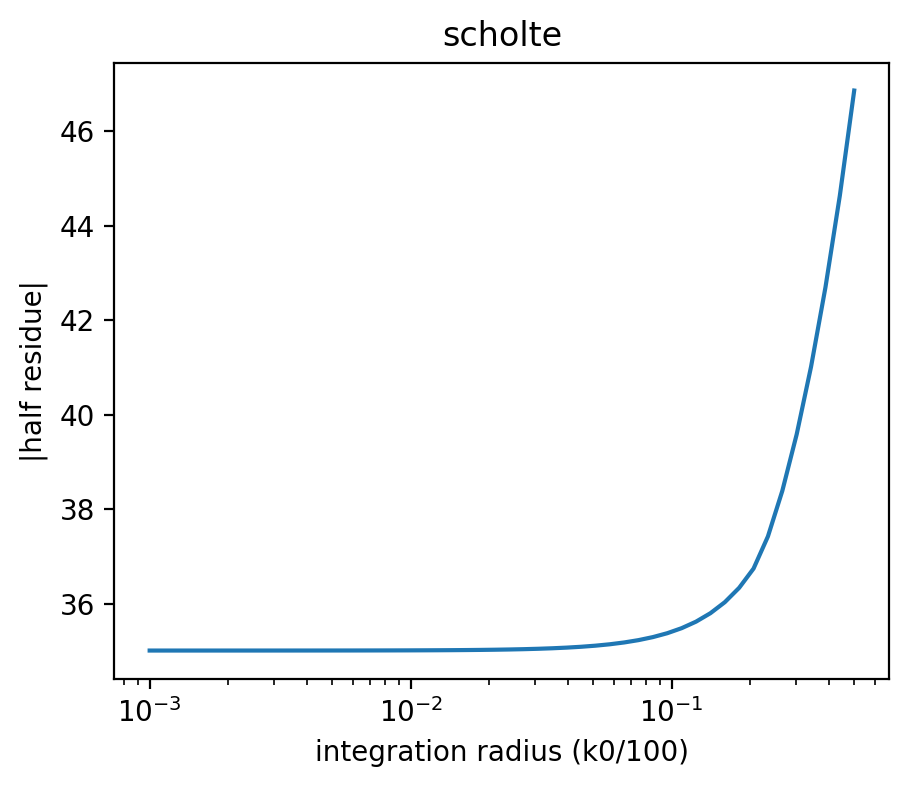

In [23]:
radii = np.geomspace(1e-3, 0.5)
residues = np.zeros(len(radii))

for i, rad in enumerate(radii):
    radius = rad * k0/100
    res = half_residue(fr_func, k_sch, rad=radius)
    residues[i] = abs(res)

_, ax = plt.subplots(figsize=(5, 4))
ax.semilogx(radii, residues)
ax.set(xlabel='integration radius (k0/100)', ylabel='|half residue|', title='scholte')
plt.show()

In [24]:
sch_res = half_residue(fr_func, k_sch, rad=1e-5*k0)
print(f"Half-residue SCH: {sch_res:.4f}")

Half-residue SCH: 35.0137-0.0526j


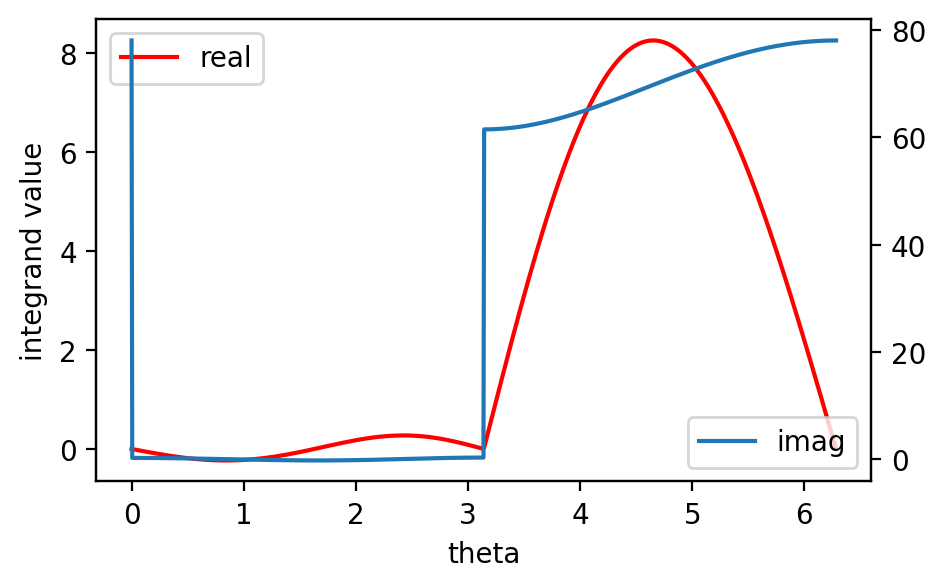

In [25]:
theta = np.linspace(0, 2 * np.pi, 1000)
rad = k0/2000

z = k_sch + rad * np.exp(1j * theta)

fr_contour =  fr_func(z) * 1j * np.exp(1j * theta) * rad

fig, ax = plt.subplots(figsize=(5, 3))
axt = ax.twinx()
ax.plot(theta, np.real(fr_contour), color='r', label='real')
axt.plot(theta, np.imag(fr_contour), label='imag')
ax.set(xlabel='theta', ylabel='integrand value')
ax.legend(), axt.legend()
plt.show()

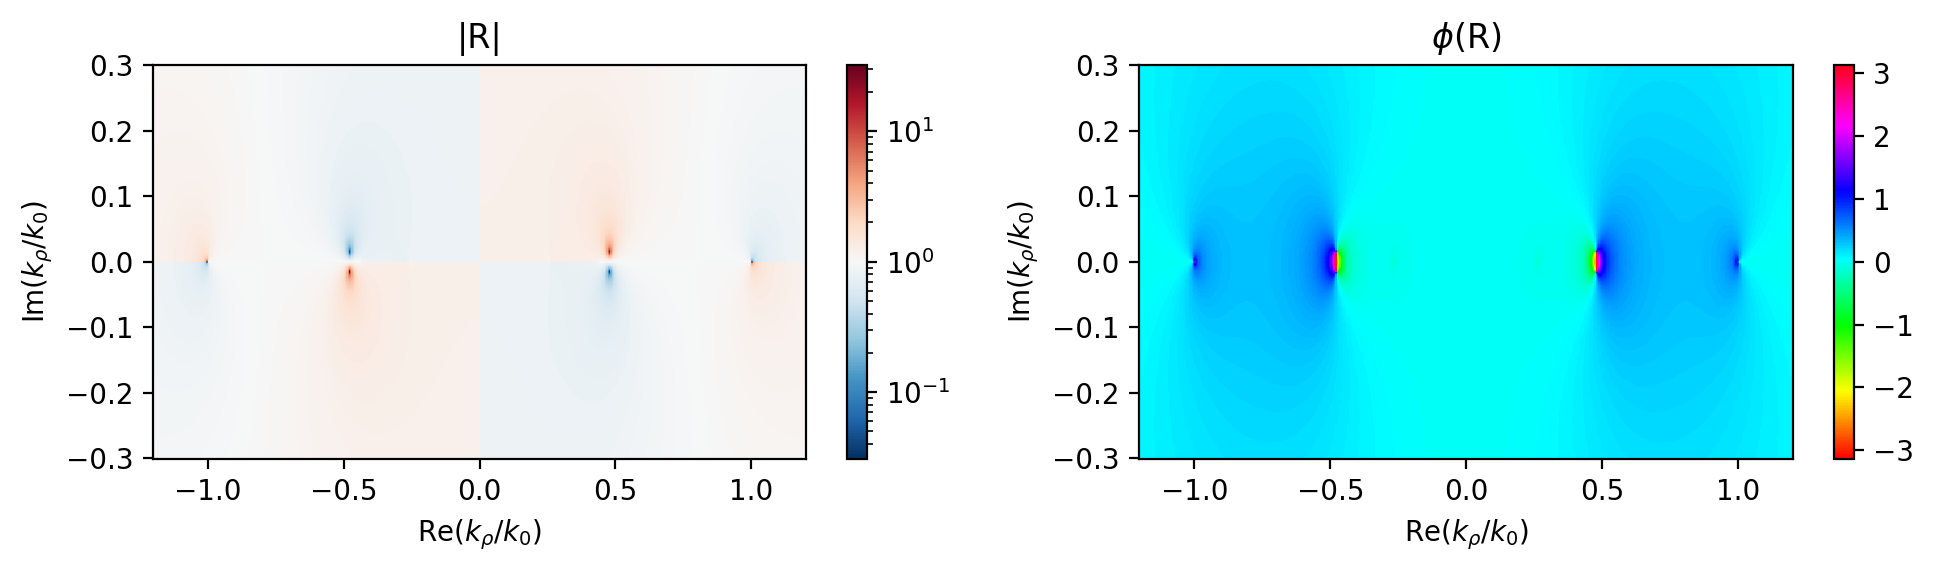

In [26]:
kpr = np.linspace(-1.2, 1.2, 500)
kpi = np.linspace(-.3, .3, 500)
krr, kii = np.meshgrid(kpr, kpi)
fresnel_r = fr_func((krr + kii * 1j) * k0)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
imr = ax[0].pcolormesh(kpr, kpi, np.abs(fresnel_r), norm=mpl.colors.LogNorm(), cmap='RdBu_r')
imi = ax[1].pcolormesh(kpr, kpi, np.angle(fresnel_r), norm=mpl.colors.CenteredNorm(), cmap='hsv')

ax[0].set(xlabel='Re($k_{\\rho}/k_0$)', ylabel='Im($k_{\\rho}/k_0$)', title='|R|', aspect='auto')
ax[1].set(xlabel='Re($k_{\\rho}/k_0$)', ylabel='Im($k_{\\rho}/k_0$)', title='$\\phi$(R)', aspect='auto')
plt.colorbar(imr, ax=ax[0]), plt.colorbar(imi, ax=ax[1])
plt.tight_layout()
plt.show()

### impedance residue relation

In [27]:
z_vals = np.linspace(0.1, 0.9, 10)

residues_sch = np.zeros(len(z_vals))
residues_lrw = np.zeros(len(z_vals))

for i, z in enumerate(z_vals):
    _freq = 2e6

    quartz = ElasticMedium(density=2650, sound_speed_longitudinal=5900, sound_speed_transversal=3400)
    z_q = quartz.c_transversal * quartz.density

    fluid = FluidMedium(density=np.sqrt(z_q*z), sound_speed_longitudinal=np.sqrt(z_q*z))
    z_w = fluid.c_longitudinal * fluid.density
    k0 = fluid.wavenumber(_freq)

    ms = MediumSystem([fluid, quartz])
    fr_func = lambda kp: ms.fresnel_r(kp, _freq)
    
    k_lrw = find_k_lrw(k0, fluid.density, quartz.density, quartz.wavenumber(_freq), quartz.wavenumber_transversal(_freq))
    k_sch = find_k_sch_prec(k0, fluid.density, quartz.density, quartz.wavenumber(_freq), quartz.wavenumber_transversal(_freq))

    residues_sch[i] = abs(residue(fr_func, k_sch, rad=0.1 * k0/100))
    residues_lrw[i] = abs(residue(fr_func, k_lrw, rad=0.1 * np.imag(k_lrw)))
    

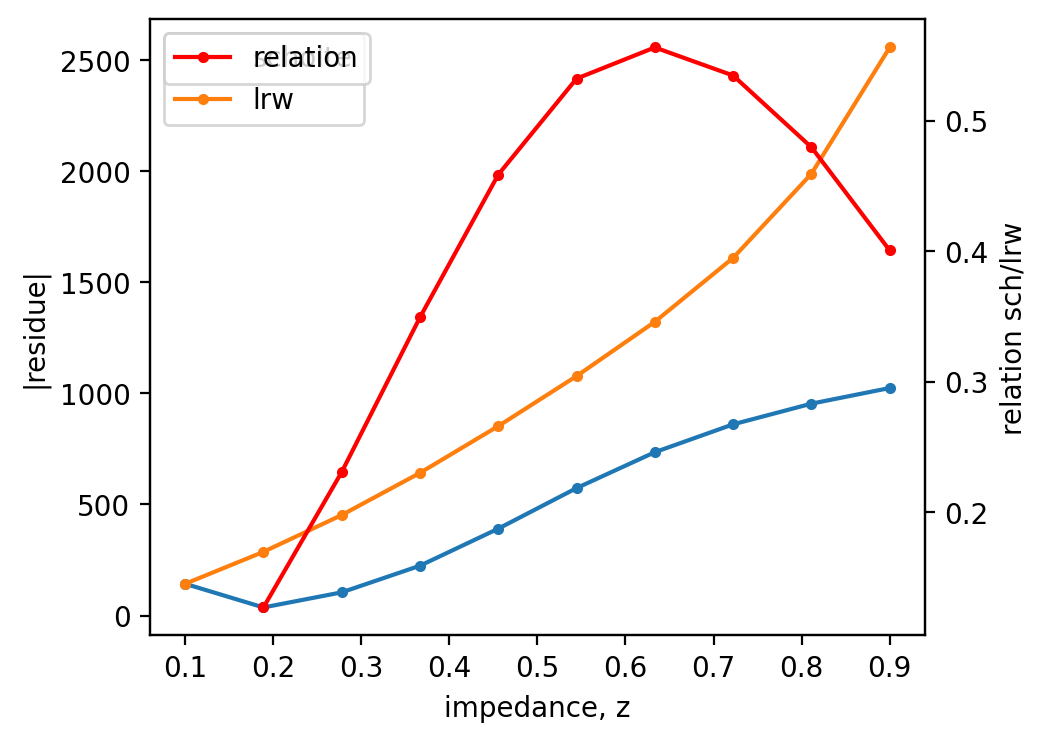

In [28]:
_, ax = plt.subplots(figsize=(5, 4))
ax.plot(z_vals, residues_sch, marker='.', label='scholte')
ax.plot(z_vals, residues_lrw, marker='.', label='lrw')
axt = ax.twinx()
axt.plot(z_vals[1:], residues_sch[1:] / residues_lrw[1:], color='r', marker='.', label='relation')
ax.set(xlabel='impedance, z', ylabel='|residue|'), axt.set(ylabel='relation sch/lrw')
ax.legend(), axt.legend()
plt.show()

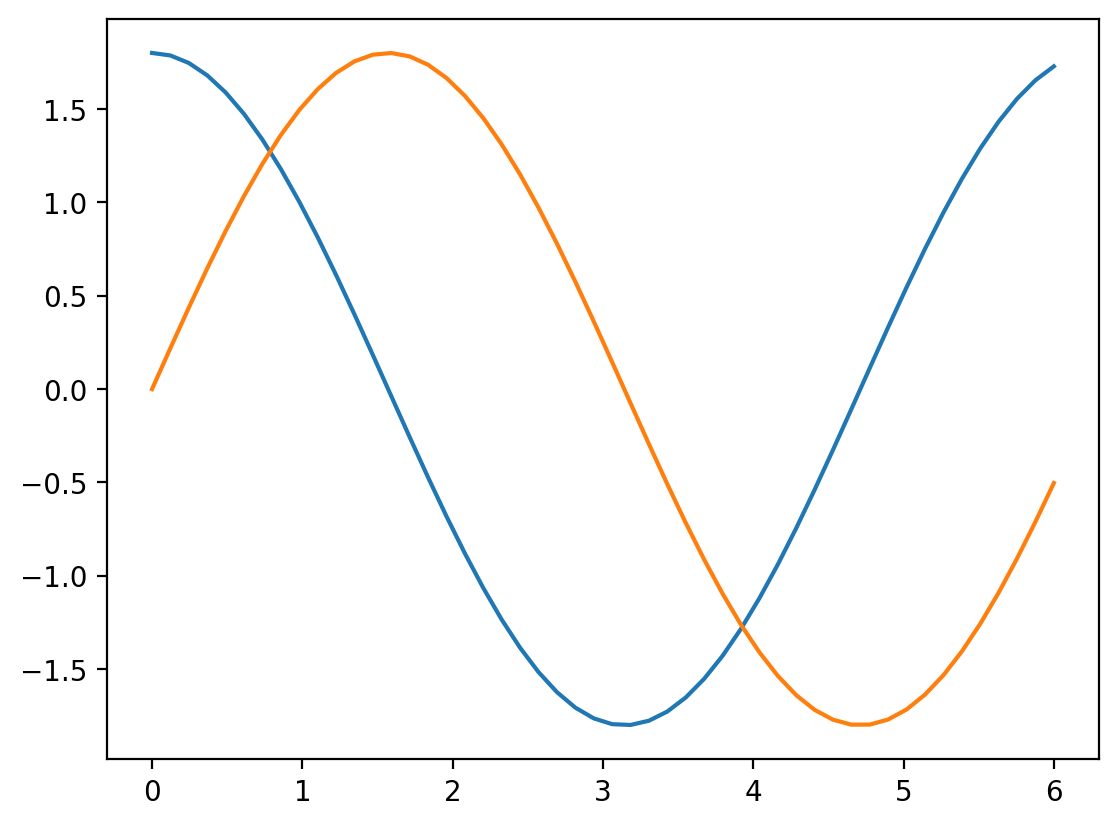

In [44]:
x = np.linspace(0, 6)
pi = np.exp(1j*1*x)
pr = 0.8*np.exp(1j*1*x)

plt.plot(x, np.real(pi + pr))
plt.plot(x, np.imag(pi + pr))

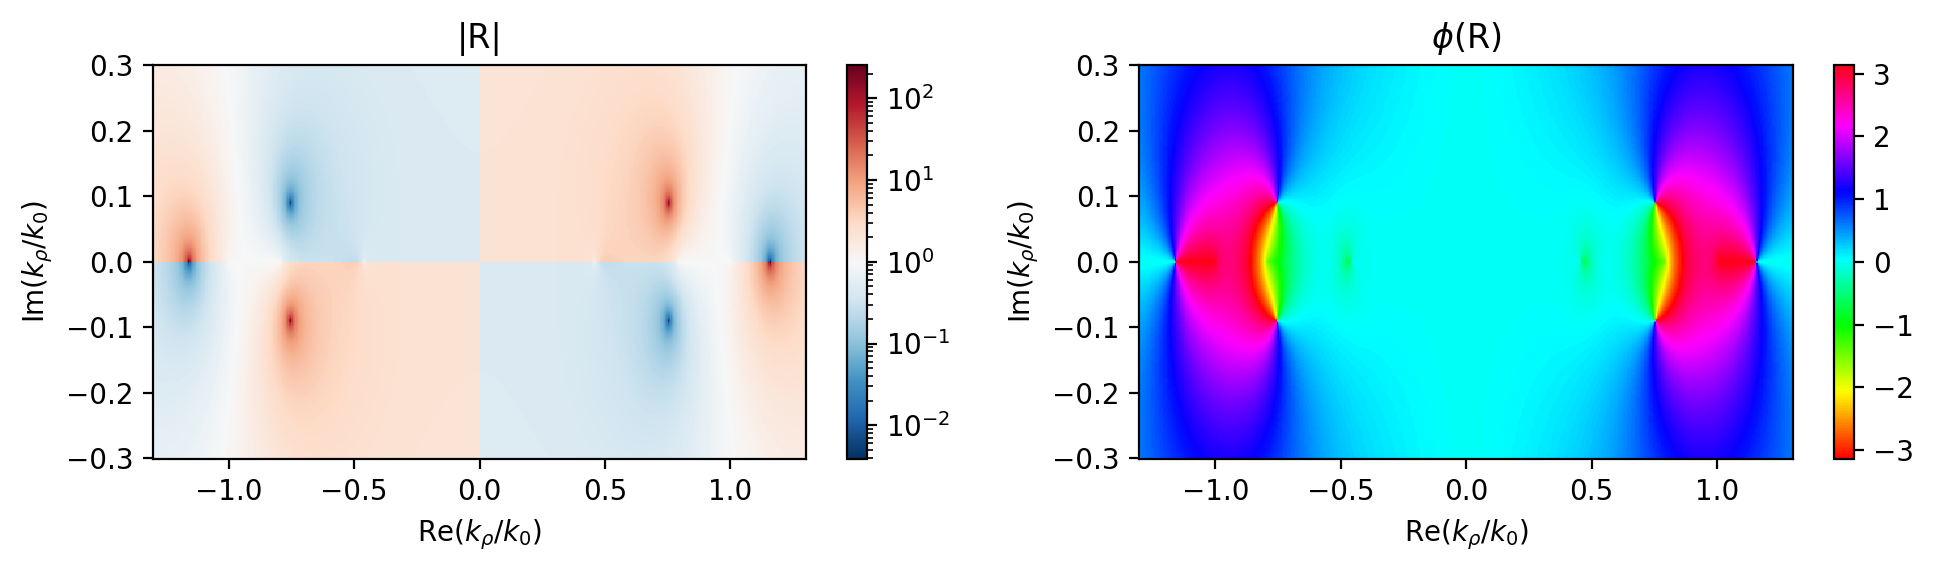

0.6592674805771365

In [29]:
quartz = ElasticMedium(density=2650, sound_speed_longitudinal=5900, sound_speed_transversal=3400)
liquid = FluidMedium(density=2200, sound_speed_longitudinal=2700)
ms = MediumSystem([liquid, quartz])

k0 = liquid.wavenumber(_freq)
fr_func = lambda kp: ms.fresnel_r(kp, _freq)

kpr = np.linspace(-1.3, 1.3, 500)
kpi = np.linspace(-.3, .3, 500)
krr, kii = np.meshgrid(kpr, kpi)
fresnel_r = fr_func((krr + kii * 1j) * k0)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
imr = ax[0].pcolormesh(kpr, kpi, np.abs(fresnel_r), norm=mpl.colors.LogNorm(), cmap='RdBu_r')
imi = ax[1].pcolormesh(kpr, kpi, np.angle(fresnel_r), norm=mpl.colors.CenteredNorm(), cmap='hsv')

ax[0].set(xlabel='Re($k_{\\rho}/k_0$)', ylabel='Im($k_{\\rho}/k_0$)', title='|R|', aspect='auto')
ax[1].set(xlabel='Re($k_{\\rho}/k_0$)', ylabel='Im($k_{\\rho}/k_0$)', title='$\\phi$(R)', aspect='auto')
plt.colorbar(imr, ax=ax[0]), plt.colorbar(imi, ax=ax[1])
plt.tight_layout()
plt.show()

liquid.c_longitudinal*liquid.density / (quartz.c_transversal*quartz.density)

### force contributions

In [30]:
quartz = ElasticMedium(density=2650, sound_speed_longitudinal=5900, sound_speed_transversal=3400)
water = FluidMedium(density=1000, sound_speed_longitudinal=1500)
ms = MediumSystem([water, quartz])

k0 = water.wavenumber(_freq)

fr_func = lambda kp: ms.fresnel_r(kp, _freq)

k_sch = find_k_sch_prec(k0, water.density, quartz.density, quartz.wavenumber(_freq), quartz.wavenumber_transversal(_freq))
k_lrw = find_k_lrw(k0, water.density, quartz.density, quartz.wavenumber(_freq), quartz.wavenumber_transversal(_freq))

kz_lrw = np.emath.sqrt(k0**2 - k_lrw**2)
kz_sch = np.emath.sqrt(k0**2 - k_sch**2)

sch_res = residue(fr_func, k_sch, rad=0.0005*k0)
lrw_res = residue(fr_func, k_lrw, rad=0.1 * np.imag(k_lrw))


In [31]:
import scipy.special as ss

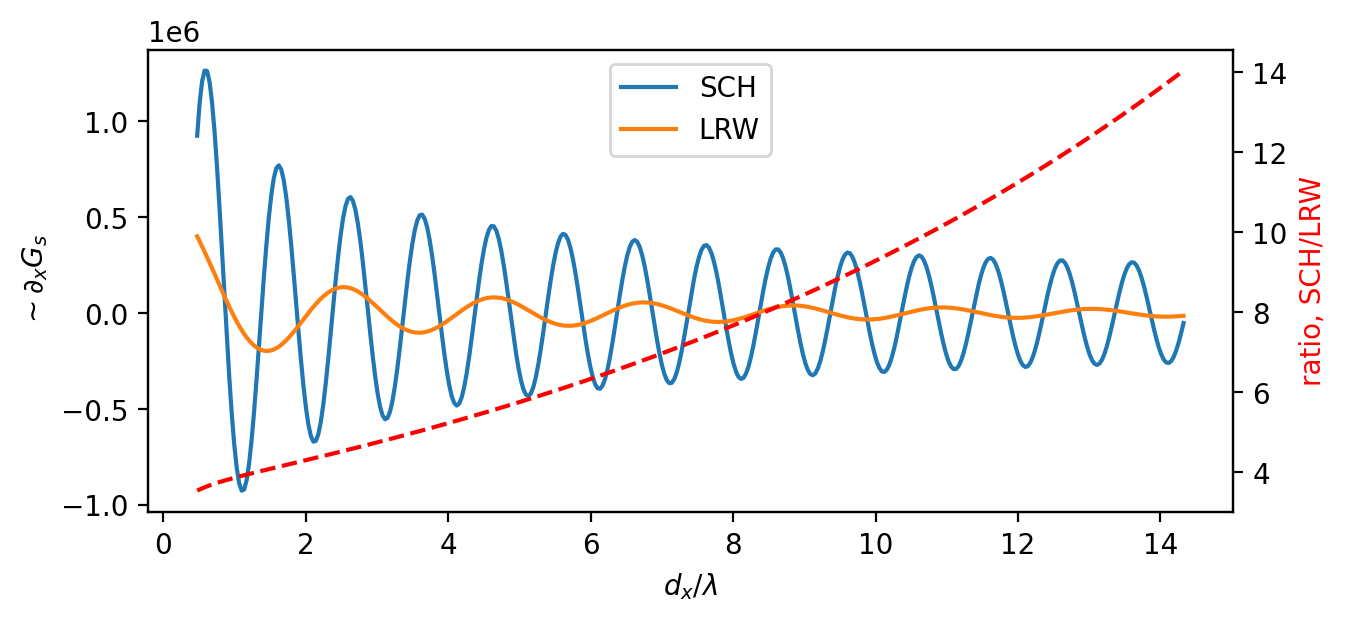

In [32]:
r_particle = 1 / k0
hz = 3 * r_particle
r_p = np.linspace(3, 90, 400) * r_particle


fr_res = sch_res
k_p = k_sch
k_z = np.emath.sqrt(k0**2 - k_p**2)
ggx_sch = fr_res * np.exp(2j * k_z * hz) * ss.hankel1(1, k_p * r_p) * k_p ** 2 / k_z


fr_res = lrw_res
k_p = k_lrw
k_z = np.emath.sqrt(k0**2 - k_p**2)
ggx_lrw = fr_res * np.exp(2j * k_z * hz) * ss.hankel1(1, k_p * r_p) * k_p ** 2 / k_z


fig, ax = plt.subplots(figsize=(7, 3))
axt = ax.twinx()

ax.plot(k0 * r_p /2/np.pi, np.real(ggx_sch), label='SCH')
ax.plot(k0 * r_p /2/np.pi, np.real(ggx_lrw), label='LRW')
axt.plot(k0 * r_p /2/np.pi, np.abs(ggx_sch) / np.abs(ggx_lrw), c='r', ls='--')

ax.set(xlabel='$d_x/\\lambda$', ylabel='$\\sim\\partial_x G_s$'), ax.legend(loc='upper center')
axt.set(ylabel='ratio, SCH/LRW'), axt.yaxis.label.set_color('r')
plt.show()

In [33]:
print(f"k-SCH: {k_sch/k0:.4f}")
print(f"k-LRW: {k_lrw/k0:.4f}")
print(f"k_z ratio (SCH/LRW): {abs(kz_lrw/kz_sch):.2f}")

print('')

print(f"R-residue SCH: {sch_res:.2f}")
print(f"R-residue LRW: {lrw_res:.2f}")
print(f"R-residue ratio (LRW/SCH): {abs(lrw_res/sch_res):.2f}")

print('')

part_sch = k_sch**2 * sch_res / kz_sch
part_lrw = k_lrw**2 * lrw_res / kz_lrw
print(f"total constant ratio (SCH/LRW): {abs( part_sch / part_lrw):.2f}")


sch_exp = np.exp(2j * kz_sch * hz)
lrw_exp = np.exp(2j * kz_lrw * hz)
print(f"eikzz ratio (SCH/LRW): {abs(sch_exp/lrw_exp):.2f}")

k-SCH: 1.0021+0.0000j
k-LRW: 0.4776+0.0152j
k_z ratio (SCH/LRW): 13.54

R-residue SCH: 35.01-2.64j
R-residue LRW: -70.66+250.58j
R-residue ratio (LRW/SCH): 7.41

total constant ratio (SCH/LRW): 8.03
eikzz ratio (SCH/LRW): 0.64


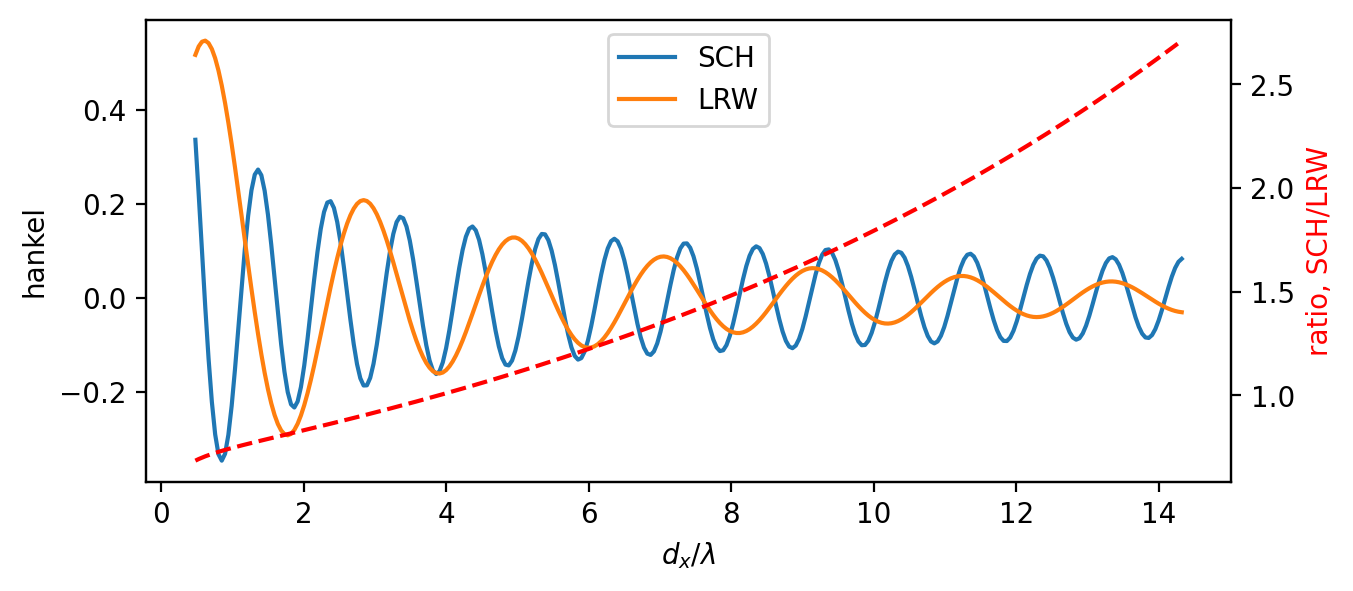

In [34]:
r_particle = 1 / k0
hz = 3 * r_particle
r_p = np.linspace(3, 90, 300) * r_particle


fr_res = sch_res
k_p = k_sch
k_z = np.emath.sqrt(k0**2 - k_p**2)
ggx_sch = ss.hankel1(1, k_p * r_p)


fr_res = lrw_res
k_p = k_lrw
k_z = np.emath.sqrt(k0**2 - k_p**2)
ggx_lrw = ss.hankel1(1, k_p * r_p)


fig, ax = plt.subplots(figsize=(7, 3))
axt = ax.twinx()

ax.plot(k0 * r_p /2/np.pi, np.real(ggx_sch), label='SCH')
ax.plot(k0 * r_p /2/np.pi, np.real(ggx_lrw), label='LRW')
axt.plot(k0 * r_p /2/np.pi, np.abs(ggx_sch) / np.abs(ggx_lrw), c='r', ls='--')

ax.set(xlabel='$d_x/\\lambda$', ylabel='hankel'), ax.legend(loc='upper center')
axt.set(ylabel='ratio, SCH/LRW'), axt.yaxis.label.set_color('r')
plt.show()

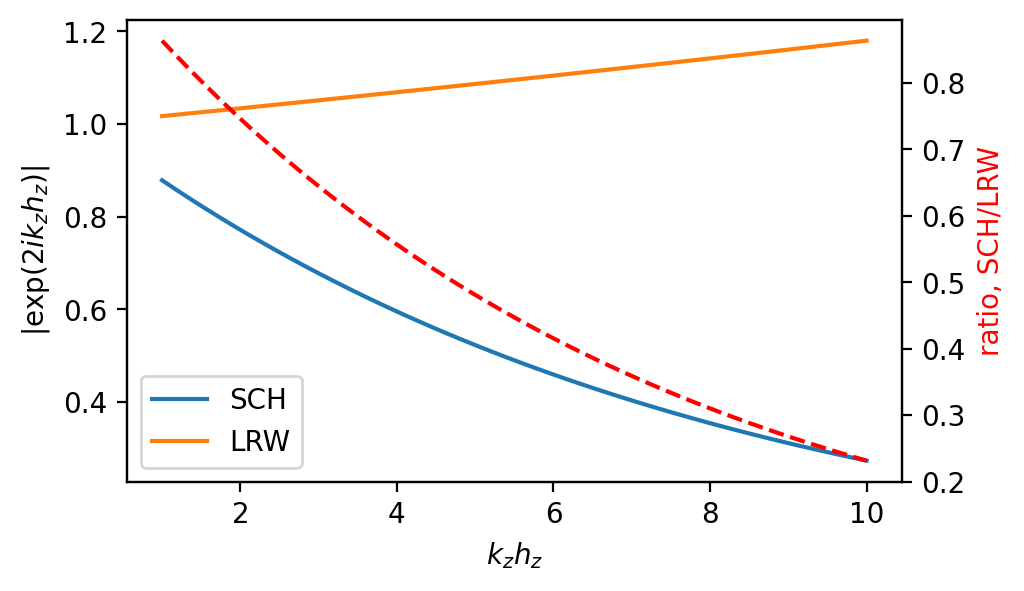

In [35]:
r_particle = 1 / k0
hz = np.linspace(1, 10) * r_particle

fr_res = sch_res
k_p = k_sch
k_z = np.emath.sqrt(k0**2 - k_p**2)
ggx_sch = np.exp(2j * k_z * hz)


fr_res = lrw_res
k_p = k_lrw
k_z = np.emath.sqrt(k0**2 - k_p**2)
ggx_lrw = np.exp(2j * k_z * hz)


fig, ax = plt.subplots(figsize=(5, 3))
axt = ax.twinx()

ax.plot(k0 * hz, np.abs(ggx_sch), label='SCH')
ax.plot(k0 * hz, np.abs(ggx_lrw), label='LRW')
axt.plot(k0 * hz, np.abs(ggx_sch) / np.abs(ggx_lrw), c='r', ls='--')

ax.set(xlabel='$k_zh_z$', ylabel='|exp($2ik_zh_z$)|'), ax.legend()
axt.set(ylabel='ratio, SCH/LRW'), axt.yaxis.label.set_color('r')
plt.show()

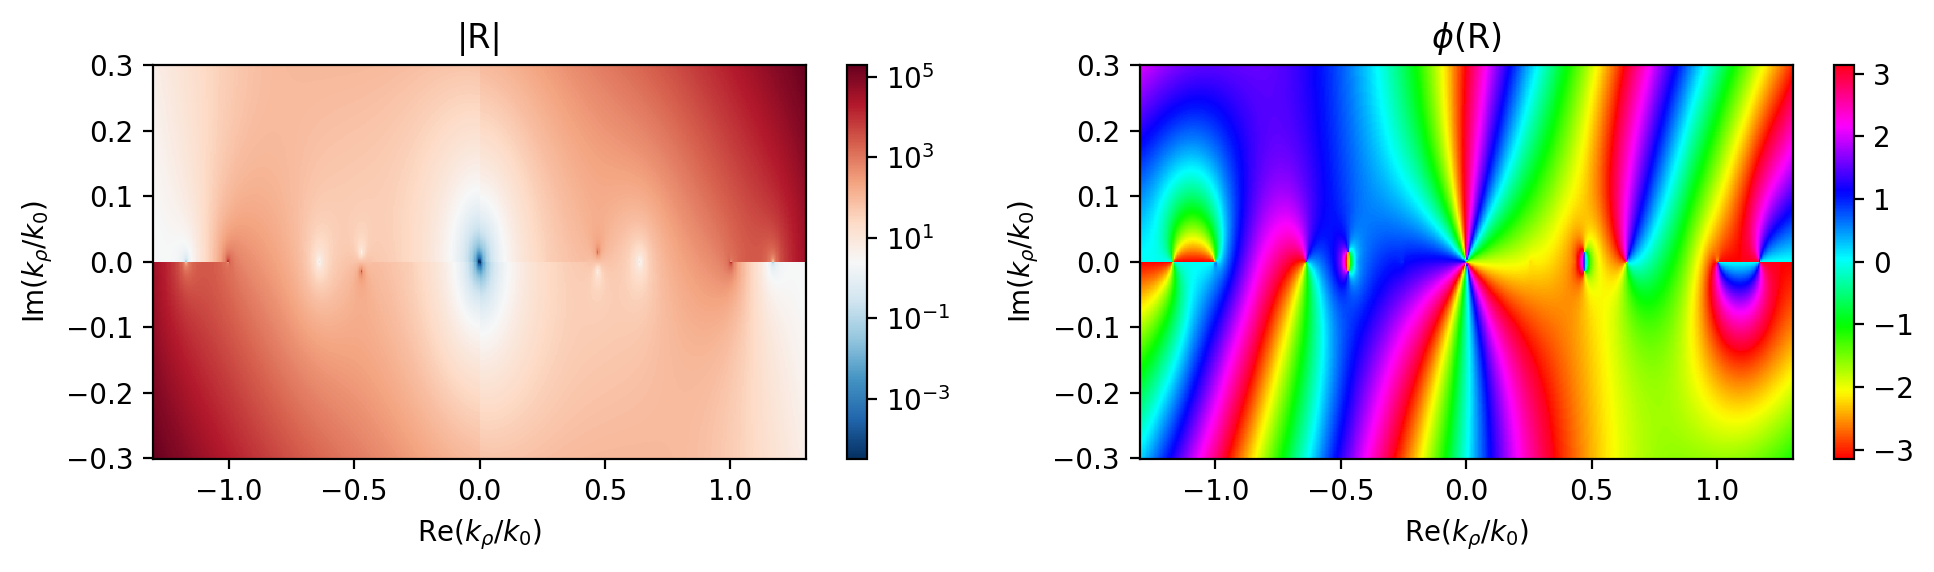

In [36]:
quartz = ElasticMedium(density=2650, sound_speed_longitudinal=5900, sound_speed_transversal=3400)
liquid = FluidMedium(density=1000, sound_speed_longitudinal=1480)
ms = MediumSystem([liquid, quartz])

k0 = liquid.wavenumber(_freq)
fr_func = lambda kp: ms.fresnel_r(kp, _freq)

kpr = np.linspace(-1.3, 1.3, 500)
kpi = np.linspace(-.3, .3, 500)
krr, kii = np.meshgrid(kpr, kpi)
k_p = (krr + kii * 1j) * k0

r_particle = 1 / k0
hz = 3 * r_particle
fresnel_r = fr_func(k_p)
k_z = np.emath.sqrt(k0**2-k_p**2)
intj = -1j/4/np.pi * fr_func(k_p) * np.exp(2j * k_z * hz) * ss.jn(1, k_p * (2*hz)) * k_p ** 2 / k_z

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
imr = ax[0].pcolormesh(kpr, kpi, np.abs(intj), norm=mpl.colors.LogNorm(), cmap='RdBu_r')
imi = ax[1].pcolormesh(kpr, kpi, np.angle(intj), norm=mpl.colors.CenteredNorm(), cmap='hsv')

ax[0].set(xlabel='Re($k_{\\rho}/k_0$)', ylabel='Im($k_{\\rho}/k_0$)', title='|R|', aspect='auto')
ax[1].set(xlabel='Re($k_{\\rho}/k_0$)', ylabel='Im($k_{\\rho}/k_0$)', title='$\\phi$(R)', aspect='auto')
plt.colorbar(imr, ax=ax[0]), plt.colorbar(imi, ax=ax[1])
plt.tight_layout()
plt.show()

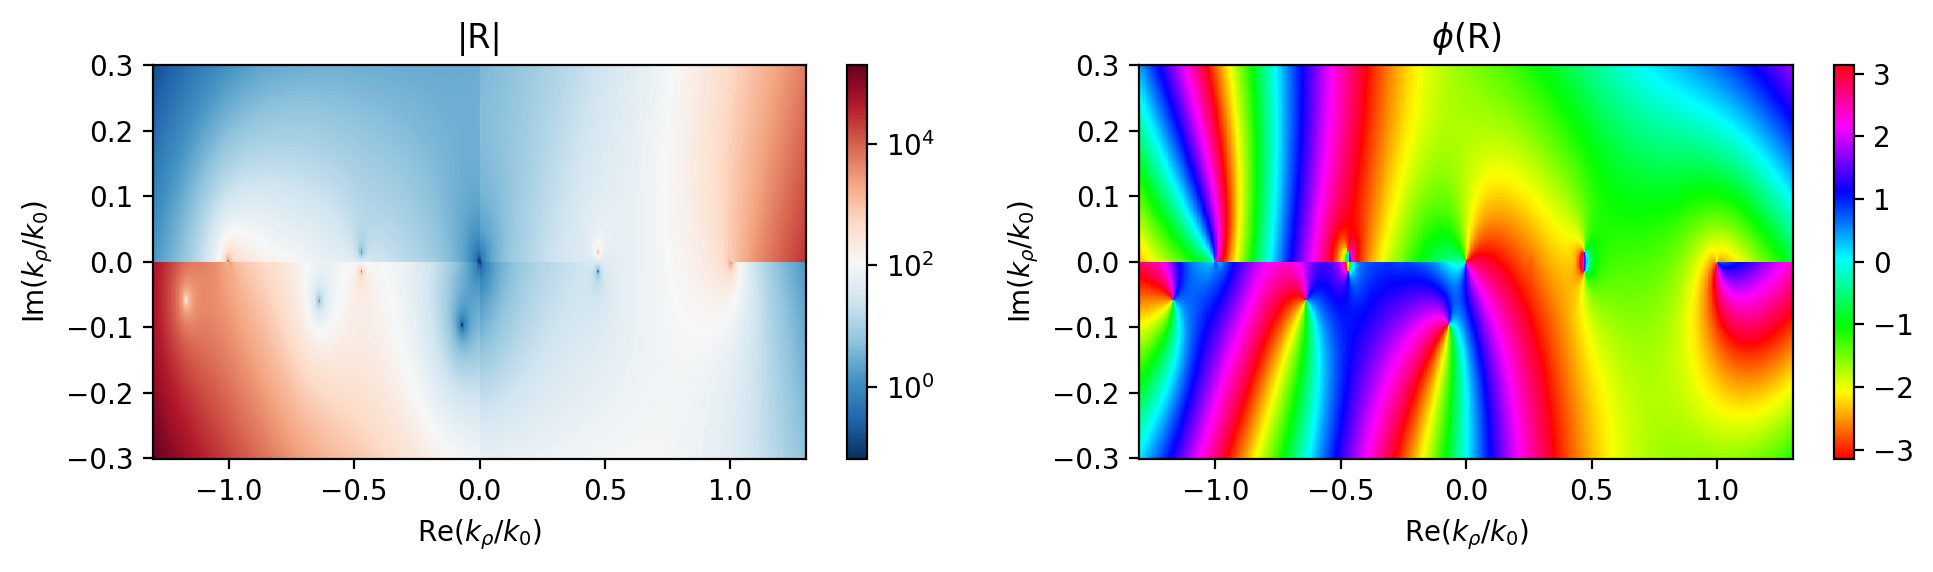

In [37]:
quartz = ElasticMedium(density=2650, sound_speed_longitudinal=5900, sound_speed_transversal=3400)
liquid = FluidMedium(density=1000, sound_speed_longitudinal=1480)
ms = MediumSystem([liquid, quartz])

k0 = liquid.wavenumber(_freq)
fr_func = lambda kp: ms.fresnel_r(kp, _freq)

kpr = np.linspace(-1.3, 1.3, 500)
kpi = np.linspace(-.3, .3, 500)
krr, kii = np.meshgrid(kpr, kpi)
k_p = (krr + kii * 1j) * k0

r_particle = 1 / k0
hz = 3 * r_particle
fresnel_r = fr_func(k_p)
k_z = np.emath.sqrt(k0**2-k_p**2)
inth = -1j/8/np.pi * fr_func(k_p) * np.exp(2j * k_z * hz) * ss.hankel1(1, k_p * (2*hz)) * k_p ** 2 / k_z

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
imr = ax[0].pcolormesh(kpr, kpi, np.abs(inth), norm=mpl.colors.LogNorm(), cmap='RdBu_r')
imi = ax[1].pcolormesh(kpr, kpi, np.angle(inth), norm=mpl.colors.CenteredNorm(), cmap='hsv')

ax[0].set(xlabel='Re($k_{\\rho}/k_0$)', ylabel='Im($k_{\\rho}/k_0$)', title='|R|', aspect='auto')
ax[1].set(xlabel='Re($k_{\\rho}/k_0$)', ylabel='Im($k_{\\rho}/k_0$)', title='$\\phi$(R)', aspect='auto')
plt.colorbar(imr, ax=ax[0]), plt.colorbar(imi, ax=ax[1])
plt.tight_layout()
plt.show()

In [ ]:
rubber = ElasticMedium(density=3800, sound_speed_longitudinal=1100, sound_speed_transversal=150)
liquid = FluidMedium(density=1000, sound_speed_longitudinal=1480)
ms = MediumSystem([liquid, rubber])

k0 = liquid.wavenumber(_freq)
fr_func = lambda kp: ms.fresnel_r(kp, _freq)

kpr = np.linspace(-10, 10, 500)
kpi = np.linspace(-.3, .3, 500)
krr, kii = np.meshgrid(kpr, kpi)
k_p = (krr + kii * 1j) * k0

r_particle = 1 / k0
hz = 3 * r_particle
fresnel_r = fr_func(k_p)
k_z = np.emath.sqrt(k0**2-k_p**2)
inth = -1j/8/np.pi * fr_func(k_p) * np.exp(2j * k_z * hz) * ss.hankel1(1, k_p * (2*hz)) * k_p ** 2 / k_z

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
imr = ax[0].pcolormesh(kpr, kpi, np.abs(inth), norm=mpl.colors.LogNorm(), cmap='RdBu_r')
imi = ax[1].pcolormesh(kpr, kpi, np.angle(inth), norm=mpl.colors.CenteredNorm(), cmap='hsv')

ax[0].set(xlabel='Re($k_{\\rho}/k_0$)', ylabel='Im($k_{\\rho}/k_0$)', title='|R|', aspect='auto')
ax[1].set(xlabel='Re($k_{\\rho}/k_0$)', ylabel='Im($k_{\\rho}/k_0$)', title='$\\phi$(R)', aspect='auto')
plt.colorbar(imr, ax=ax[0]), plt.colorbar(imi, ax=ax[1])
plt.tight_layout()
plt.show()

In [38]:
def gamma_cont(func, pole, rad):

    def integrand(theta):
        z = pole + rad * np.exp(1j * theta)
        return func(z) * 1j * np.exp(1j * theta) * rad

    return si.quad(integrand, np.pi, 2 * np.pi, complex_func=True)[0]


jn_int = gamma_cont(fr_func, k_sch, rad=1e-4*k0)
hn_res = residue(fr_func, k_sch, rad=1e-4*k0)

jn_int / (2*np.pi*1j), hn_res

((0.1955339381194716-0.18658045188856937j),
 (-1.8041124150158796e-16+2.42861286636753e-16j))

In [39]:
quartz = ElasticMedium(density=2650, sound_speed_longitudinal=5900, sound_speed_transversal=3400)
water = FluidMedium(density=1000, sound_speed_longitudinal=1480)
ms = MediumSystem([water, quartz])

k0 = water.wavenumber(_freq)
fr_func = lambda kp: ms.fresnel_r(kp, _freq)
r_particle = 1 / k0
hz = 3 * r_particle

k_sch = find_k_sch_prec(k0, water.density, quartz.density, quartz.wavenumber(_freq), quartz.wavenumber_transversal(_freq))
k_lrw = find_k_lrw(k0, water.density, quartz.density, quartz.wavenumber(_freq), quartz.wavenumber_transversal(_freq))


def ggx_intj(k_p):
    k_z = np.emath.sqrt(k0**2-k_p**2)
    return -1j/4/np.pi * fr_func(k_p) * np.exp(2j * k_z * hz) * ss.jn(1, k_p * (2*hz)) * k_p ** 2 / k_z

def ggx_inth(k_p):
    k_z = np.emath.sqrt(k0**2-k_p**2)
    return -1j/8/np.pi * fr_func(k_p) * np.exp(2j * k_z * hz) * ss.hankel1(1, k_p * (2*hz)) * k_p ** 2 / k_z

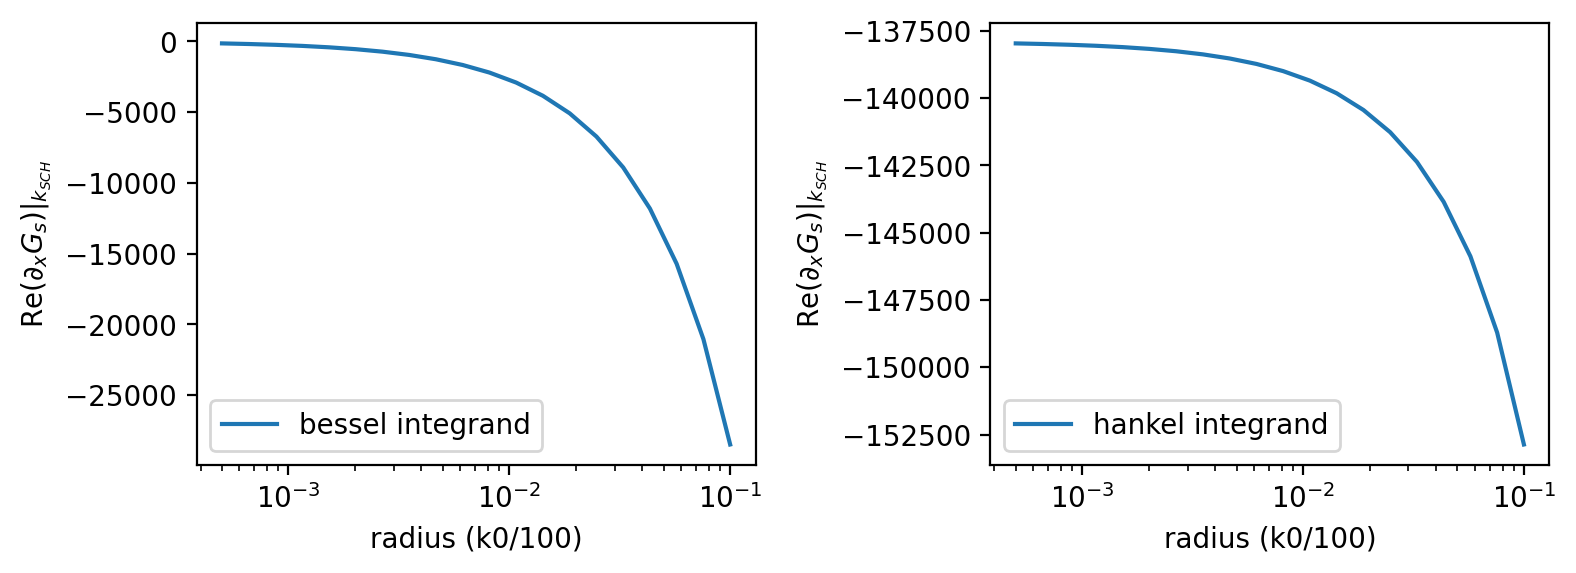

In [40]:
scales = np.geomspace(5e-4, 1e-1, 20)
jvals = np.zeros_like(scales)
hvals = np.zeros_like(scales)
for i, scale in enumerate(scales):
    jvals[i] = np.real(gamma_cont(ggx_intj, k_sch, rad=scale*k0/100))
    hvals[i] = np.real(2*np.pi*1j * residue(ggx_inth, k_sch, rad=scale*k0/100))
    
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].semilogx(scales, jvals, label='bessel integrand')
ax[1].semilogx(scales, hvals, label='hankel integrand')
ax[0].set(xlabel='radius (k0/100)', ylabel='Re$(\partial_x G_s)|_{k_{SCH}}$')
ax[1].set(xlabel='radius (k0/100)', ylabel='Re$(\partial_x G_s)|_{k_{SCH}}$')
ax[0].legend(), ax[1].legend()
plt.tight_layout()

In [41]:
-1j / 4 / np.pi * jn_int, 0.25 * hn_res

((0.0977669690597358-0.09329022594428468j),
 (-4.510281037539699e-17+6.071532165918825e-17j))

In [ ]:
r_particle = 1 / k0
r_p = np.linspace(0.5, 40, 1000) * r_particle

jn_sch = ss.jn(1, k_sch * r_p)
hn_sch = ss.hankel1(1, k_sch * r_p)

fig, ax = plt.subplots(figsize=(7, 3))

ax.plot(k0 * r_p /2/np.pi, jn_sch, lw=2, label='Re(J1)')
ax.plot(k0 * r_p /2/np.pi, np.imag(jn_sch), label='Im(J1)', lw=1)
ax.plot(k0 * r_p /2/np.pi, np.real(hn_sch), lw=2, ls='--',label='Re(H1)')
ax.plot(k0 * r_p /2/np.pi, np.imag(hn_sch), lw=2, ls=':',label='Im(H1)')

ax.set(xlabel='$d_x/\\lambda$', ylabel='bessel / hankel'), ax.legend()
plt.show()

ValueError: operands could not be broadcast together with shapes (500,500) (1000,) 

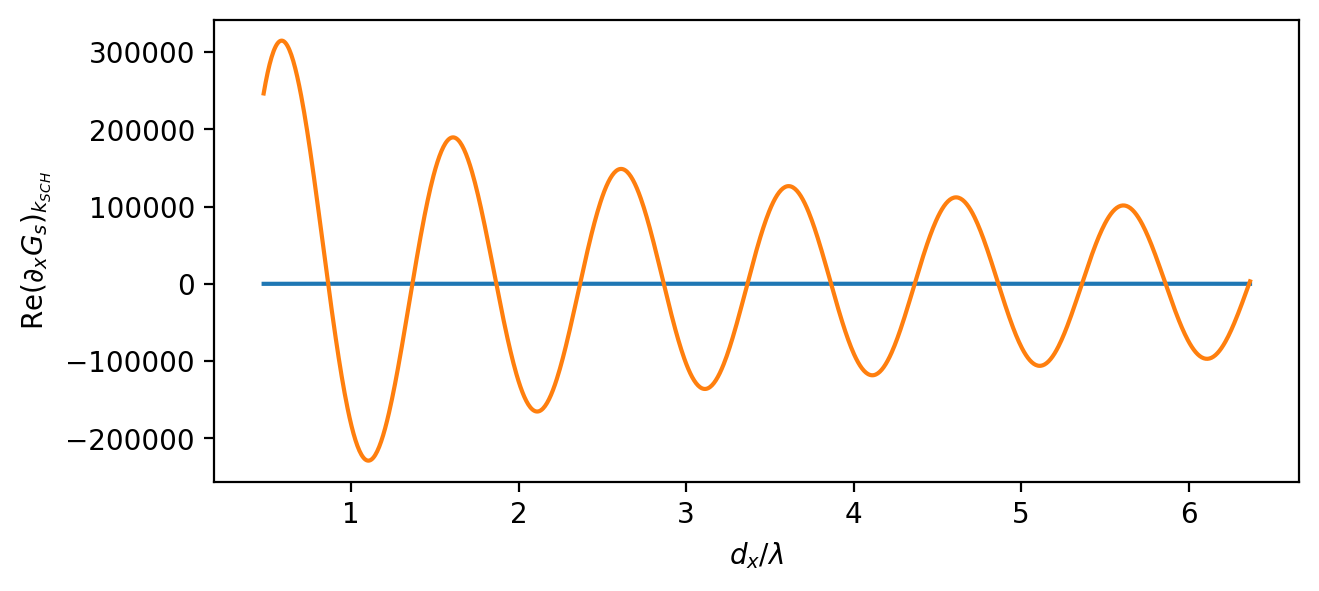

In [ ]:
r_particle = 1 / k0
hz = 3.2 * r_particle
r_p = np.linspace(3, 40, 1000) * r_particle

k_p = k_sch
k_z = np.emath.sqrt(k0**2 - k_p**2)

g_cont = gamma_cont(fr_func, k_sch, rad=1e-6*k0)
ggxj = -1j/4/np.pi * g_cont * np.exp(2j * k_z * hz) * ss.jn(1, k_p * r_p) * k_p ** 2 / k_z

fr_res = residue(fr_func, k_sch, rad=1e-6*k0)
ggxh = 0.25 * fr_res * np.exp(2j * k_z * hz) * ss.hankel1(1, k_p * r_p) * k_p ** 2 / k_z


fig, ax = plt.subplots(figsize=(7, 3))

ax.plot(k0 * r_p /2/np.pi, np.real(ggxj), label='with bessel J')
ax.plot(k0 * r_p /2/np.pi, np.real(ggxh), label='with hankel H')

ax.set(xlabel='$d_x/\\lambda$', ylabel='Re$(\partial_x G_s)_{k_{SCH}}$')
plt.show()

In [ ]:
k_p ** 2 / k_z, fr_res

(-135581.96486873322j, (33.316693593344354-0.5337403609940151j))

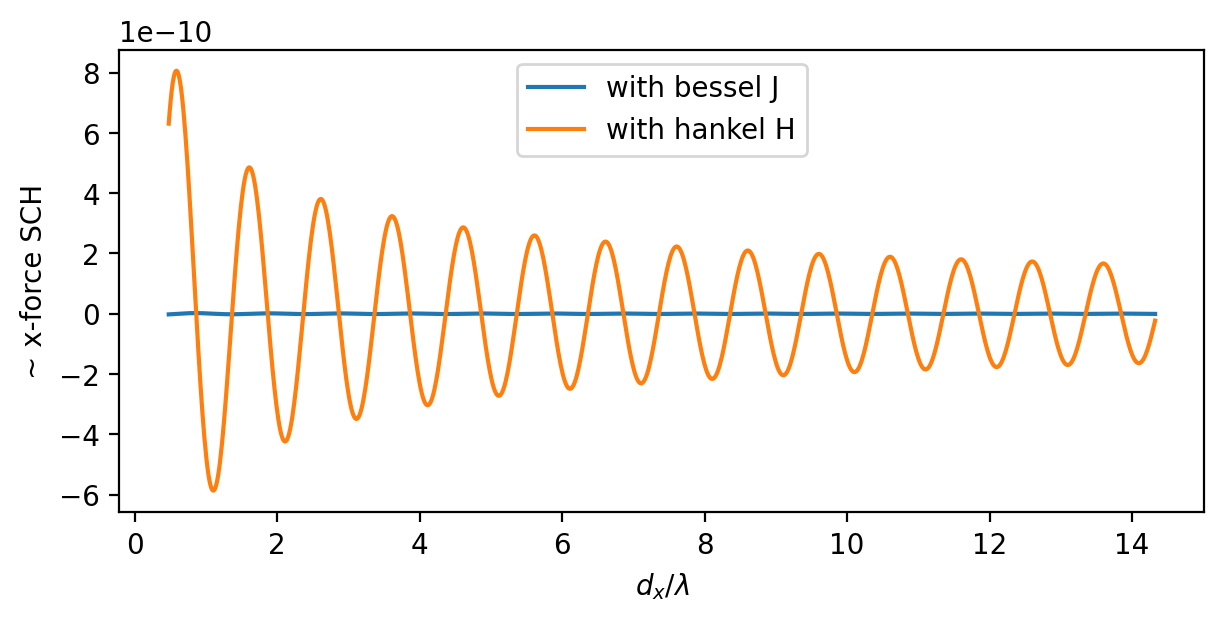

In [ ]:
r_particle = 1 / k0
hz = 3 * r_particle
r_p = np.linspace(3, 90, 1000) * r_particle

k_p = k_sch
k_z = np.emath.sqrt(k0**2 - k_p**2)

m_mom = (-1 - 2j) * 1e-9
omega = 2 * np.pi * _freq

g_cont = gamma_cont(fr_func, k_sch, rad=1e-5*k0)
ggx_j = -1j/4/np.pi * g_cont * np.exp(2j * k_z * hz) * ss.jn(1, k_p * r_p) * k_p ** 2 / k_z
grad_psc_j = 1j * water.density * omega * ggx_j * m_mom
fj = 0.5 / omega * np.imag(np.conj(m_mom) * grad_psc_j)

fr_res = residue(fr_func, k_sch, rad=1e-5*k0)
ggx_h = 0.25 * fr_res * np.exp(2j * k_z * hz) * ss.hankel1(1, k_p * r_p) * k_p ** 2 / k_z
grad_psc_h = 1j * water.density * omega * ggx_h * m_mom
fh = 0.5 / omega * np.imag(np.conj(m_mom) * grad_psc_h)

fig, ax = plt.subplots(figsize=(7, 3))

ax.plot(k0 * r_p /2/np.pi, fj, label='with bessel J')
ax.plot(k0 * r_p /2/np.pi, fh, label='with hankel H')

ax.set(xlabel='$d_x/\\lambda$', ylabel='~ x-force SCH'), ax.legend(loc='upper center')
plt.show()

In [ ]:
def new_residue(func, pole, rad=None, N=None):
    def integrand(theta):
        z = pole + rad * np.exp(1j * theta)
        return func(z) * 1j * np.exp(1j * theta) * rad
    ths = np.linspace(0, 2 * np.pi, N)
    return si.trapezoid(integrand(ths), ths) / 2 / np.pi / 1j

new_residue(fr_func, k_sch, rad=1e-8*k0, N=10000), new_residue(fr_func, k_lrw, rad=1e-8*k0, N=1000000)

((33.32002560342408-5.3758911017238714e-05j),
 (-68.12119836049857+246.56634617020256j))

In [ ]:
_freq = 2355493
quartz = ElasticMedium(density=2650, sound_speed_longitudinal=5900, sound_speed_transversal=3400)
water = FluidMedium(density=1000, sound_speed_longitudinal=1480)
ms = MediumSystem([water, quartz])

k0 = water.wavenumber(_freq)
fr_func = lambda kp: ms.fresnel_r(kp, _freq)

k_sch = find_k_sch_prec(k0, water.density, quartz.density, quartz.wavenumber(_freq), quartz.wavenumber_transversal(_freq))

r_particle = 1 / k0
print(r_particle)
alpha = 4.1768139752365475e-12+1.5892911221104239e-12j
prbs = np.array([water.c_longitudinal / quartz.c_transversal, water.c_longitudinal / quartz.c_longitudinal])
kcont = k_contour(imag_deflection=1e-2, step=1e-3, problems=prbs, finish=4) - 1e-15j

def g_intj(k_p, hz):
    k_z = np.emath.sqrt(k0**2-k_p**2)
    return 1j/4/np.pi * fr_func(k_p) * np.exp(2j * k_z * hz) * k_p / k_z

def green_jint(k_p, hz):
    return si.trapz(g_intj(k_p, hz), k_p)

def green_jint_corr(k_p, hz):
    k_z = np.emath.sqrt(k0**2-k_p**2)
    fresnel = gamma_cont(fr_func, k_p, rad=1e-5*k0)
    return 1j/4/np.pi * fresnel * np.exp(2j * k_z * hz) * k_p / k_z

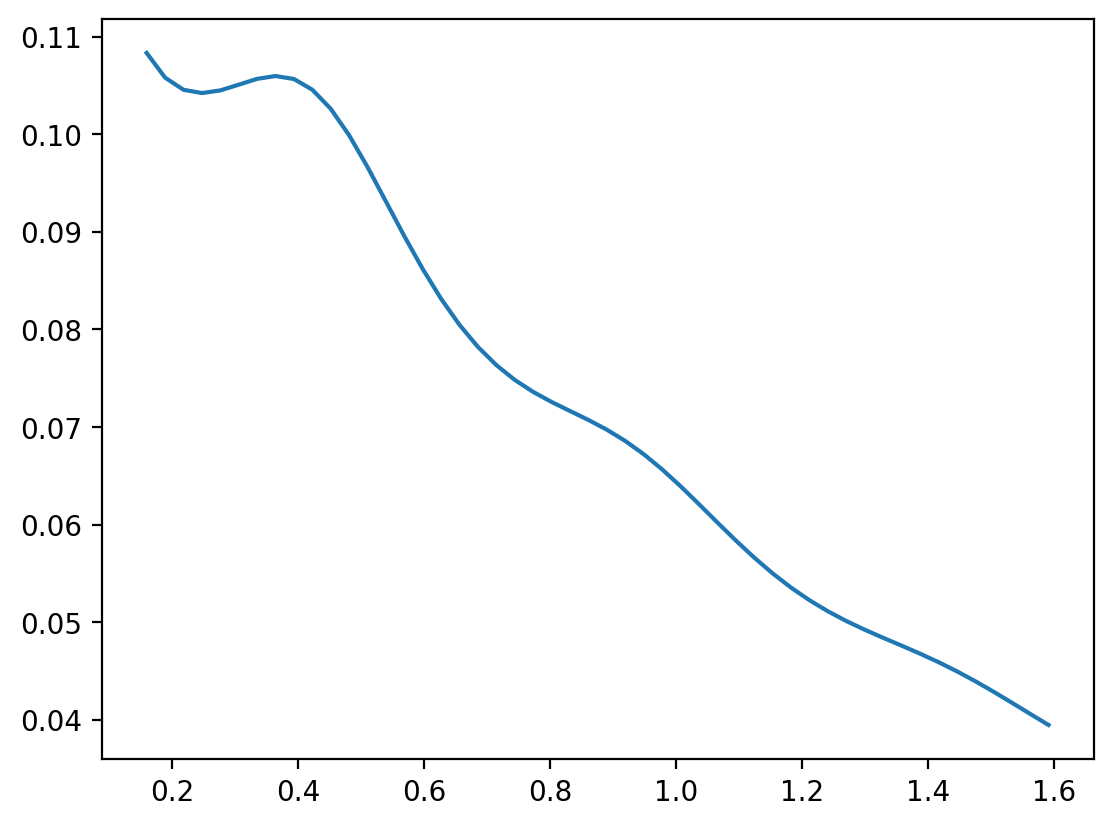

In [ ]:
heights = np.linspace(1, 10) * r_particle
aefs = np.zeros(len(heights), dtype=complex)
aefs_cor = np.zeros(len(heights), dtype=complex)

for i, h in enumerate(heights):
    aefs[i] = alpha / (1 - k0 ** 2 * green_jint(k0*kcont, h) * alpha)
    aefs_cor[i] = alpha / (1 - k0 ** 2 * (green_jint(k0*kcont, h) - green_jint_corr(k_sch, h)) * alpha)
    
    
plt.plot(heights*k0/2/np.pi, abs((aefs - aefs_cor) / aefs_cor))
# plt.plot(heights*k0, abs(aefs_cor))

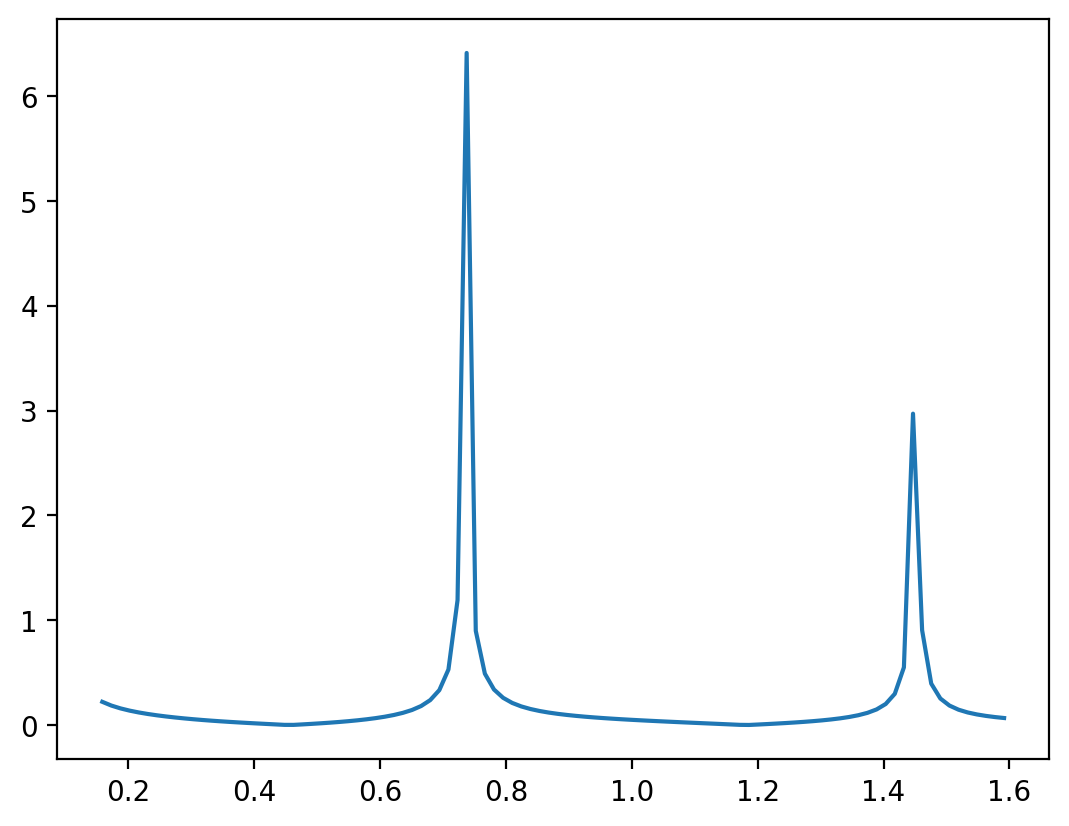

In [ ]:
beta = 1 / (water.density * water.c_longitudinal ** 2)
omega = 2 * np.pi * _freq

heights = np.linspace(1, 10, 100) * r_particle
moms = np.zeros(len(heights), dtype=complex)
moms_cor = np.zeros(len(heights), dtype=complex)

def inc_field(hz, gradient=False):
    k_vec = k0 * np.array([0.70711, 0, -0.70711])
    k_vec_s = k0 * np.array([0.70711, 0, 0.70711])
    r_vec = np.array([0, 0, hz])
    if gradient:
        return (1j * k_vec * np.exp(1j * k_vec @ r_vec) + 1j * k_vec_s * np.exp(
            1j * k_vec_s @ r_vec) * fr_func(0.70711 * k0)) * 50e3
    return 50e3 * np.exp(1j * k_vec @ r_vec) + np.exp(1j * k_vec_s @ r_vec) * fr_func(0.70711 * k0)

for i, h in enumerate(heights):
    alpha_ef = alpha / (1 - k0 ** 2 * green_jint(k0*kcont, h) * alpha)
    alpha_ef_cor = alpha / (1 - k0 ** 2 * (green_jint(k0*kcont, h) - green_jint_corr(k_sch, h)) * alpha)
    mom = - 1j * omega * beta * alpha_ef * inc_field(h)
    mom_cor = - 1j * omega * beta * alpha_ef_cor * inc_field(h)
    moms[i] = np.imag(np.conj(mom) * inc_field(h, gradient=True)[0])
    moms_cor[i] = np.imag(np.conj(mom_cor) * inc_field(h, gradient=True)[0])


plt.plot(heights*k0/2/np.pi, abs((moms - moms_cor) / moms_cor))
# plt.plot(heights*k0, np.imag(moms))
# plt.plot(heights*k0, np.imag(moms_cor))


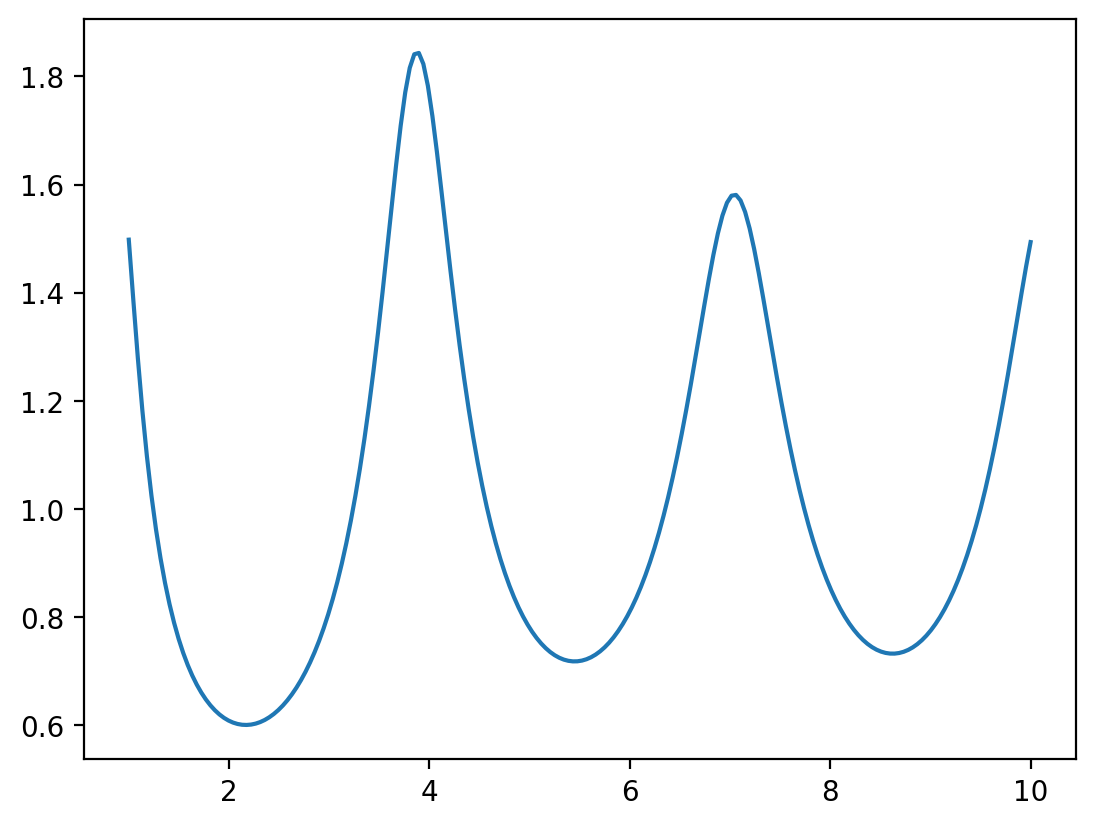

In [ ]:
heights = np.linspace(1, 10, 200) * r_particle
gss = np.zeros(len(heights), dtype=complex)
gss_corr = np.zeros(len(heights), dtype=complex)

for i, h in enumerate(heights):
    gss[i] = green_jint(k0*kcont, h)
    gss_corr[i] = green_jint(k0*kcont, h) - green_jint_corr(k_sch, h)
    
# plt.plot(heights*k0, np.imag(gss))
# plt.plot(heights*k0, np.imag(gss_corr), ls='--')
plt.plot(heights*k0, np.abs((gss- gss_corr)/gss_corr))


In [ ]:
# fig, ax = plt.subplots()


# fr_res = sch_res
# k_p = k_sch
# k_z = np.emath.sqrt(k0**2 - k_p**2)

# r_particle = 1 / k0
# hz = 3 * r_particle
# r_p = np.linspace(3, 15) * r_particle

# g = -0.25 * fr_res * np.exp(2j * k_z * r_p) * ss.hankel1(0, k_p * r_p) * k_p / k_z
# plt.plot(k0 * r_p, abs(g))


# fr_res = lrw_res
# k_p = k_lrw
# k_z = np.emath.sqrt(k0**2 - k_p**2)

# r_particle = 1 / k0
# hz = 3 * r_particle
# r_p = np.linspace(3, 15) * r_particle

# g = -0.25 * fr_res * np.exp(2j * k_z * r_p) * ss.hankel1(0, k_p * r_p) * k_p / k_z
# plt.plot(k0 * r_p, abs(g))

In [ ]:
# from acsmuthi.utility.mathematics import spherical_h1n

# def green_0(k, rp, derivative=False):
#     if derivative:
#         return 1j * k ** 2 / 4 / np.pi * spherical_h1n(0, k * rp, derivative=True)
#     else:
#         return 1j * k / 4 / np.pi * spherical_h1n(0, k * rp)



# fig, ax = plt.subplots()


# fr_res = sch_res
# k_p = k_sch
# k_z = np.emath.sqrt(k0**2 - k_p**2)

# r_particle = 1 / k0
# hz = 3 * r_particle
# r_p = np.linspace(3, 15) * r_particle

# alpha = 1
# green_s = -0.25 * fr_res * np.exp(2j * k_z * r_p) * ss.hankel1(0, k_p * r_p) * k_p / k_z
# ga1 = (green_0(k0, r_p) + green_s) * alpha
# alpha_ef = alpha / (1 - k0 ** 4 * ga1 * ga1)
# plt.plot(r_p * k0, abs(alpha_ef))


# fr_res = lrw_res
# k_p = k_lrw
# k_z = np.emath.sqrt(k0**2 - k_p**2)

# r_particle = 1 / k0
# hz = 3 * r_particle
# r_p = np.linspace(3, 15) * r_particle

# alpha = 1
# green_s = -0.25 * fr_res * np.exp(2j * k_z * r_p) * ss.hankel1(0, k_p * r_p) * k_p / k_z
# ga1 = (green_0(k0, r_p) + green_s) * alpha
# alpha_ef = alpha / (1 - k0 ** 4 * ga1 * ga1)
# plt.plot(r_p * k0, abs(alpha_ef))


In [8]:
def gamma_cont(func, pole, rad):

    def integrand(theta):
        z = pole + rad * np.exp(1j * theta)
        return func(z) * 1j * np.exp(1j * theta) * rad

    return si.quad(integrand, np.pi, 2 * np.pi, complex_func=True)[0]


def new_gamma_cont(func, pole, rad=None, N=None):
    
    def integrand(theta):
        z = pole + rad * np.exp(1j * theta)
        return func(z) * 1j * np.exp(1j * theta) * rad
    
    ths = np.linspace(np.pi, 2 * np.pi, N)
    return si.trapezoid(integrand(ths), ths)


def find_k_sch_prec(kf, rho_f, rho_s, kl, kt):
    def ray_opt(k):
        gl = np.emath.sqrt(k**2 - kl**2)
        gt = np.emath.sqrt(k**2 - kt**2)
        gf = np.emath.sqrt(kf**2 - k**2)
        return (2 * k**2 - kt**2)**2 - 4 * k**2 * gl * gt + 1j * rho_f / rho_s * kt**4 * gl / gf
    return root_scalar(ray_opt, x0=kt, x1=kt*1.2).root

c:\Users\kvd\AppData\Local\pypoetry\Cache\virtualenvs\acsmuthi-TZOMr8Wr-py3.11\Lib\site-packages\scipy\integrate\_quadpack_py.py:445: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  re_retval = quad(refunc, a, b, args, full_output, epsabs,


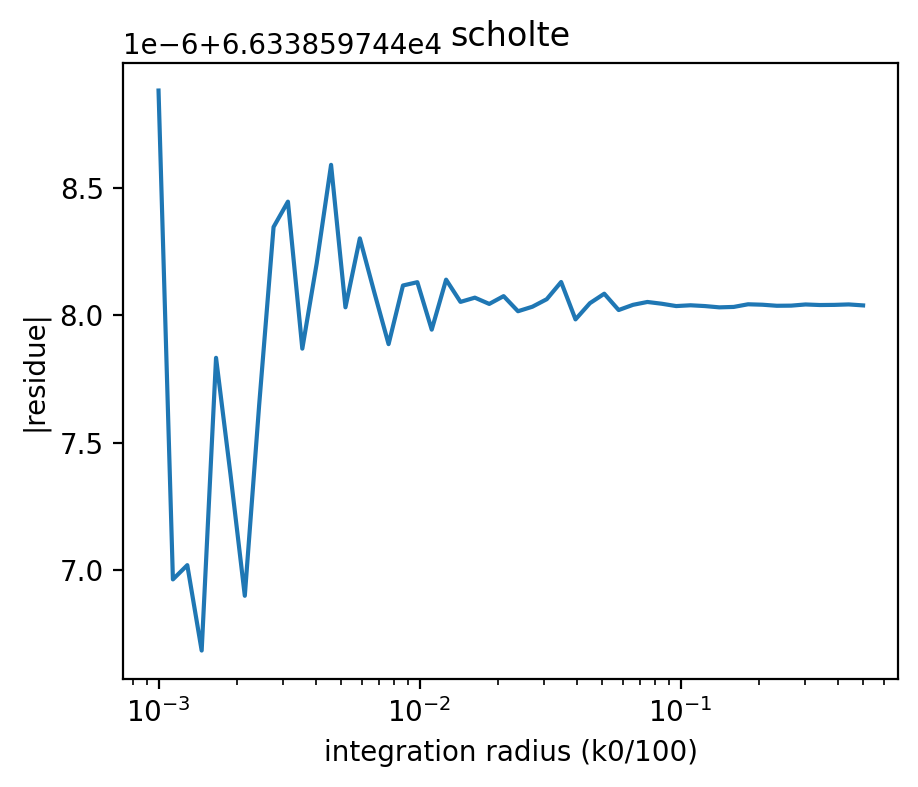

In [13]:
rubber = ElasticMedium(density=1300, sound_speed_longitudinal=1650, sound_speed_transversal=150)
water = FluidMedium(density=1000, sound_speed_longitudinal=1500)
ms = MediumSystem([water, rubber])

k0 = water.wavenumber(_freq)

fr_func = lambda kp: ms.fresnel_r(kp, _freq)

# k_lrw = find_k_lrw(k0, water.density, rubber.density, rubber.wavenumber(_freq), rubber.wavenumber_transversal(_freq))
k_sch = find_k_sch_prec(k0, water.density, rubber.density, rubber.wavenumber(_freq), rubber.wavenumber_transversal(_freq))


radii = np.geomspace(1e-3, 0.5)
residues = np.zeros(len(radii))

for i, rad in enumerate(radii):
    radius = rad * k0/100
    res = gamma_cont(fr_func, k_sch, rad=radius)
    residues[i] = np.imag(res)

_, ax = plt.subplots(figsize=(5, 4))
ax.semilogx(radii, residues)
ax.set(xlabel='integration radius (k0/100)', ylabel='|residue|', title='scholte')
plt.show()